# Import Required Libraries

This cell imports all the required Python libraries for data loading, data preprocessing, data visualization, feature selection, machine learning model development, and model evaluation. It also suppresses warning messages to keep the notebook output clean.

In [1]:
# ===============================
# CELL 1: IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Data preprocessing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif


# Models
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


# XGBoost
from xgboost import XGBClassifier


# LightGBM
from lightgbm import LGBMClassifier


# CatBoost
from catboost import CatBoostClassifier


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


print("Libraries Imported Successfully")


Libraries Imported Successfully


# Load the Dataset

This cell loads the Product Affinity dataset into a Pandas DataFrame, displays the dataset shape, and shows the first five records to verify that the data has been loaded successfully.

In [2]:
# ===============================
# CELL 2: LOAD DATASET
# ===============================

# file_path = "your_dataset_name.csv"

# df = pd.read_csv("Affinity_data.csv")
df = pd.read_csv("Affinity_data_no_leakage_target.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (50000, 21)


,Age,Gender,Region / State,Purchase Count,Total Spend,Average Order Value,Average Items Per Order,Last Purchase Days,Tenure Days,Preferred Category,...,Preferred Channel,Session Count,Engagement Score,Campaign Engagement Score,Email Click Rate,Campaign Conversion Rate,Loyalty Score,Value Score,Purchase Frequency,Target
0,26.0,Female,North,10,16743.86,1765.46,4.52,9,261,Electronics,...,WhatsApp,6,65.19,59.75,0.271,0.092,57.85,24.01,1.1494,0
1,69.0,Male,East,1,893.12,921.01,2.22,170,429,Sports,...,Push,1,5.52,13.00,0.000,0.000,30.62,10.50,0.0699,0
2,30.0,Female,South,0,0.00,0.00,0.00,683,683,NaN,...,Email,5,47.75,51.94,0.073,0.013,26.15,27.17,0.0000,0
3,18.0,Female,South,3,6871.46,2254.82,1.73,24,479,Home,...,WhatsApp,2,25.58,24.73,0.007,0.001,39.23,29.17,0.1879,0
4,47.0,Male,East,3,1683.22,579.37,1.17,3,406,Electronics,...,Email,55,86.81,90.54,0.352,0.036,60.59,5.08,0.2217,0


# Dataset Structure Check

This cell examines the overall structure of the dataset by:

- Displaying the total number of rows and columns.
- Listing all the feature (column) names.
- Showing the dataset information, including data types and non-null values.
- Displaying the distribution of data types across all columns.

In [3]:
# ===============================
# CELL 3: DATASET STRUCTURE CHECK
# ===============================

# Dataset shape
print("Dataset Shape:")
print(df.shape)


print("\n" + "="*50)


# Column names
print("Column Names:")
print(df.columns.tolist())


print("\n" + "="*50)


# Dataset information
print("Dataset Information:")
df.info()


print("\n" + "="*50)


# Data types count
print("Data Type Distribution:")
print(df.dtypes.value_counts())

Dataset Shape:
(50000, 21)

Column Names:
['Age', 'Gender', 'Region / State', 'Purchase Count', 'Total Spend', 'Average Order Value', 'Average Items Per Order', 'Last Purchase Days', 'Tenure Days', 'Preferred Category', 'Category Diversity', 'Preferred Channel', 'Session Count', 'Engagement Score', 'Campaign Engagement Score', 'Email Click Rate', 'Campaign Conversion Rate', 'Loyalty Score', 'Value Score', 'Purchase Frequency', 'Target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        48981 non-null  float64
 1   Gender                     48488 non-null  object 
 2   Region / State             50000 non-null  object 
 3   Purchase Count             50000 non-null  int64  
 4   Total Spend                50000 non-null  float64
 5   Average Order Value        5000

# Check Target Variable

This cell analyzes all the columns in the dataset to help identify the target variable by:

- Displaying each column name.
- Showing the number of unique values in each column.
- Displaying the data type of each column.
- Sorting the columns based on the number of unique values for easier identification of the target variable.

In [4]:
# ===============================
# CELL 4: CHECK TARGET VARIABLE
# ===============================

# Display all columns with unique value counts

target_check = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Data Type": [df[col].dtype for col in df.columns]
})


target_check.sort_values(
    by="Unique Values",
    ascending=True
)

,Column,Unique Values,Data Type
20,Target,2,int64
1,Gender,3,object
2,Region / State,5,object
11,Preferred Channel,5,object
9,Preferred Category,8,object
10,Category Diversity,9,int64
3,Purchase Count,51,int64
0,Age,68,float64
12,Session Count,93,int64
16,Campaign Conversion Rate,348,float64


# Missing Value Analysis

This cell analyzes the missing values in the dataset by:

- Counting the number of missing values in each feature.
- Calculating the percentage of missing values.
- Displaying only the features that contain missing values.
- Sorting the features in descending order based on the percentage of missing values to identify the columns that require data preprocessing.

In [5]:
# ===============================
# CELL 5: MISSING VALUE ANALYSIS
# ===============================

# Count missing values

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})


# Keep only columns having missing values

missing_values = missing_values[
    missing_values["Missing Count"] > 0
]


# Sort by highest missing percentage

missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Preferred Category,5301,10.602
Gender,1512,3.024
Age,1019,2.038


# Missing Value Visualization

This cell visualizes the percentage of missing values across the dataset using a bar chart.

The visualization helps to:

- Identify the features with missing values.
- Compare the percentage of missing values across different features.
- Determine which features require data preprocessing before model development.
- Support the selection of an appropriate missing value handling technique.

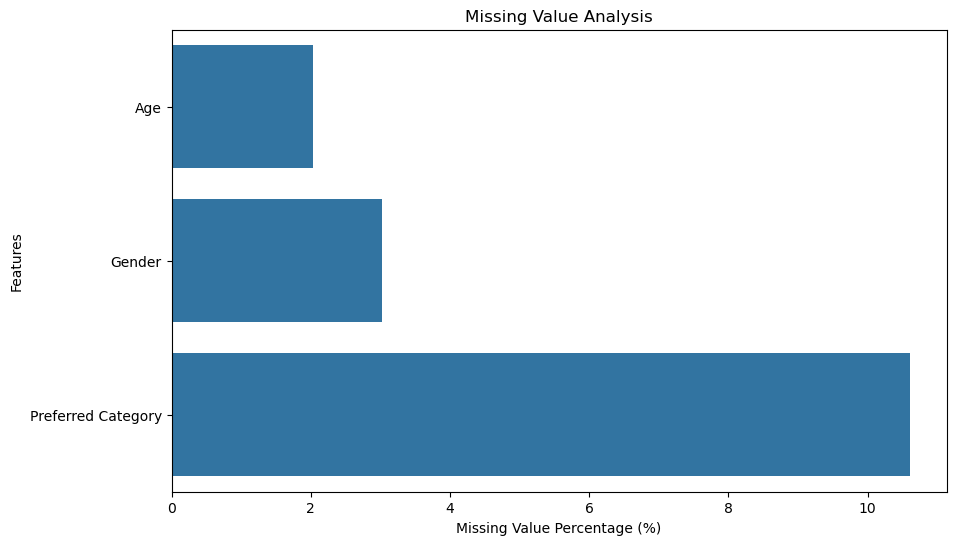

In [6]:
# ===============================
# MISSING VALUE BAR PLOT
# ===============================

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_values["Missing Percentage"],
    y=missing_values.index
)

plt.xlabel("Missing Value Percentage (%)")
plt.ylabel("Features")
plt.title("Missing Value Analysis")

plt.show()

# Duplicate Record Analysis

This cell analyzes the dataset for duplicate records by:

- Counting the total number of duplicate rows.
- Calculating the percentage of duplicate records in the dataset.
- Assessing whether duplicate records need to be removed during data preprocessing.

Duplicate record analysis is an important data quality check, as duplicate records can introduce bias, affect model performance, and lead to inaccurate predictions if not handled appropriately.

In [7]:
# ===============================
# CELL 6: DUPLICATE RECORD ANALYSIS
# ===============================

# Count duplicate rows

duplicate_count = df.duplicated().sum()


print("Number of Duplicate Records:", duplicate_count)


# Duplicate percentage

duplicate_percentage = (duplicate_count / len(df)) * 100


print(
    "Duplicate Percentage:",
    round(duplicate_percentage, 2),
    "%"
)

Number of Duplicate Records: 0
Duplicate Percentage: 0.0 %


# Duplicate Record Visualization

This cell visualizes the distribution of unique and duplicate records in the dataset using a bar chart.

The visualization helps to:

- Compare the number of unique and duplicate records.
- Assess the overall data quality of the dataset.
- Determine whether duplicate records require removal before data preprocessing and model training.

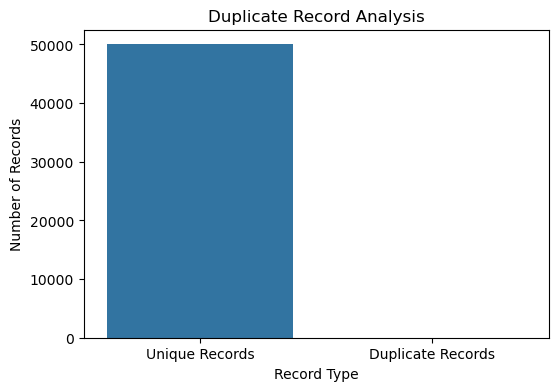

In [8]:
# ===============================
# DUPLICATE RECORD VISUALIZATION
# ===============================

duplicate_status = pd.DataFrame({
    "Status": [
        "Unique Records",
        "Duplicate Records"
    ],
    "Count": [
        len(df) - duplicate_count,
        duplicate_count
    ]
})


plt.figure(figsize=(6,4))

sns.barplot(
    data=duplicate_status,
    x="Status",
    y="Count"
)

plt.title("Duplicate Record Analysis")

plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.show()

# Statistical Summary

This cell identifies all the numerical features in the dataset and generates a statistical summary for each feature.

The statistical summary provides:

- The total number of numerical features available for analysis.
- A list of all numerical features in the dataset.
- Key descriptive statistics, including count, mean, standard deviation, minimum, maximum, and quartile values.
- A better understanding of the distribution and range of numerical features before performing exploratory data analysis (EDA) and data preprocessing.

In [9]:
# ===============================
# CELL 7: STATISTICAL SUMMARY
# ===============================

# Select numerical columns

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns


print("Number of Numerical Features:",
      len(numerical_features))


print("\nNumerical Features:")
print(list(numerical_features))


# Statistical summary

df[numerical_features].describe().T

Number of Numerical Features: 17

Numerical Features:
['Age', 'Purchase Count', 'Total Spend', 'Average Order Value', 'Average Items Per Order', 'Last Purchase Days', 'Tenure Days', 'Category Diversity', 'Session Count', 'Engagement Score', 'Campaign Engagement Score', 'Email Click Rate', 'Campaign Conversion Rate', 'Loyalty Score', 'Value Score', 'Purchase Frequency', 'Target']


,count,mean,std,min,25%,50%,75%,max
Age,48981.0,39.746881,12.449293,18.00,31.0000,39.0000,48.0000,8.500000e+01
Purchase Count,50000.0,3.836620,3.664057,0.00,1.0000,3.0000,5.0000,5.300000e+01
Total Spend,50000.0,9573.987704,17431.671981,0.00,1683.8000,4542.1150,10820.8275,1.014808e+06
Average Order Value,50000.0,1805.100423,1343.925965,0.00,972.4000,1572.1700,2389.6450,2.084226e+04
Average Items Per Order,50000.0,2.612058,1.710021,0.00,1.4500,2.4000,3.5700,1.392000e+01
Last Purchase Days,50000.0,80.533440,185.977293,1.00,11.0000,22.0000,47.0000,1.200000e+03
Tenure Days,50000.0,567.636080,397.013267,5.00,279.0000,477.0000,759.2500,3.650000e+03
Category Diversity,50000.0,1.827020,0.988958,0.00,1.0000,2.0000,2.0000,8.000000e+00
Session Count,50000.0,6.818880,7.124188,0.00,2.0000,5.0000,9.0000,1.810000e+02
Engagement Score,50000.0,49.847040,21.476447,0.00,33.3775,49.7500,66.2800,1.000000e+02


# Numerical Feature Distribution

This cell visualizes the distribution of each numerical feature using histograms with Kernel Density Estimation (KDE).

The distribution plots help to:

- Understand the distribution pattern of each numerical feature.
- Identify whether the data is normally distributed, skewed, or contains multiple peaks.
- Detect potential outliers and unusual data patterns.
- Support data preprocessing and feature engineering decisions before model development.

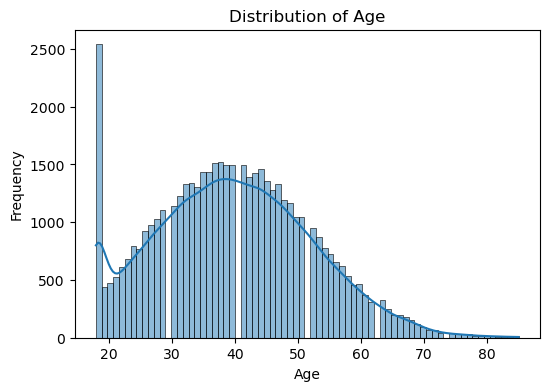

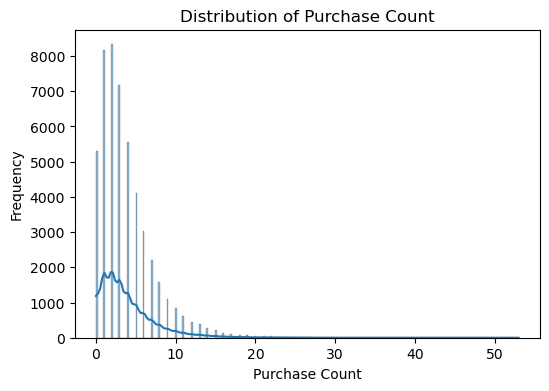

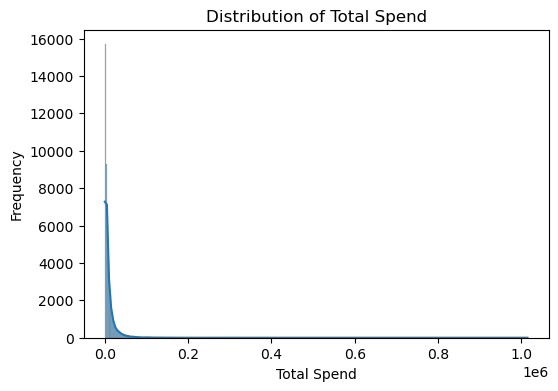

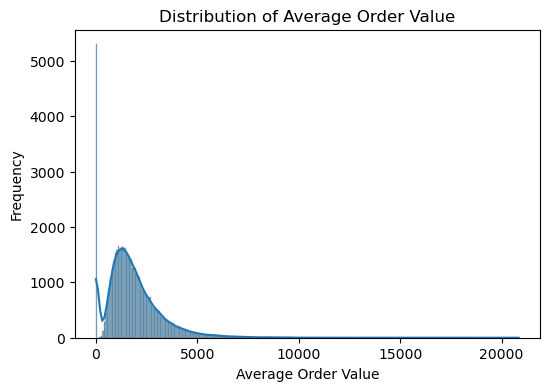

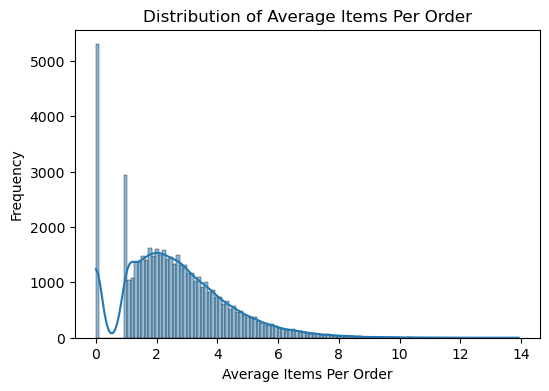

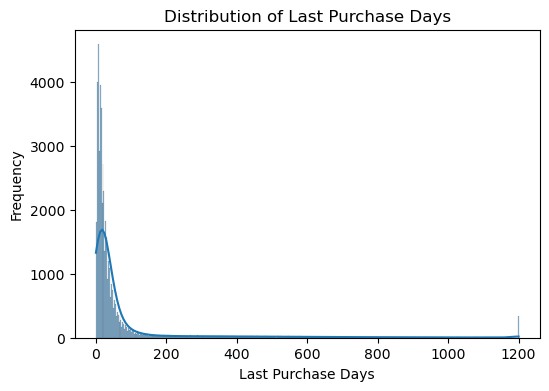

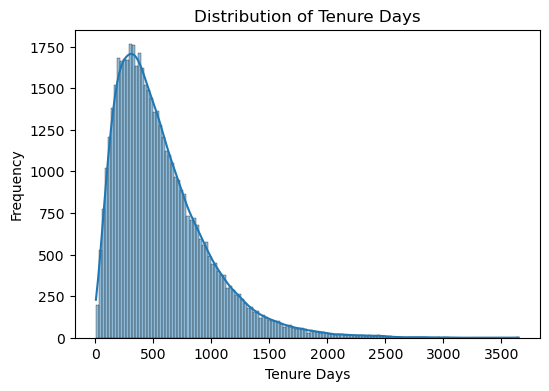

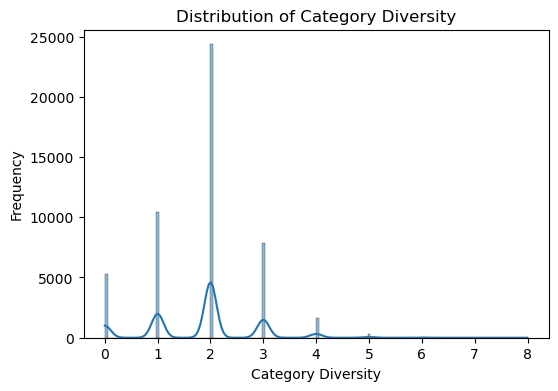

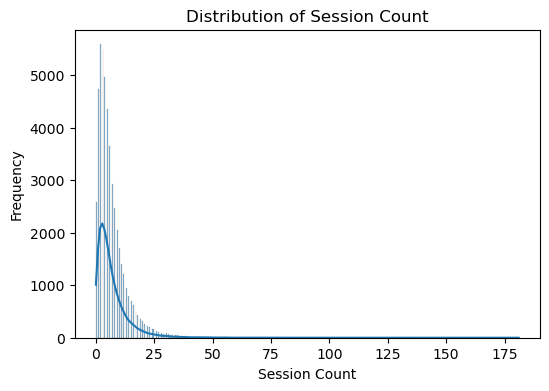

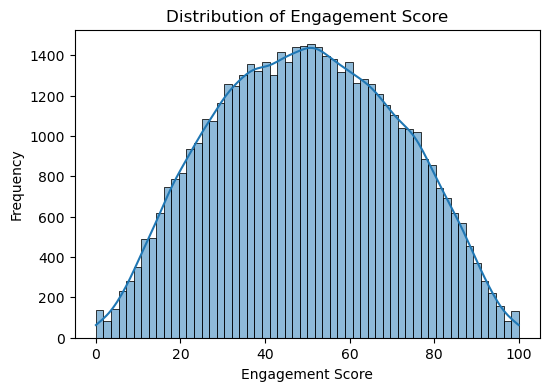

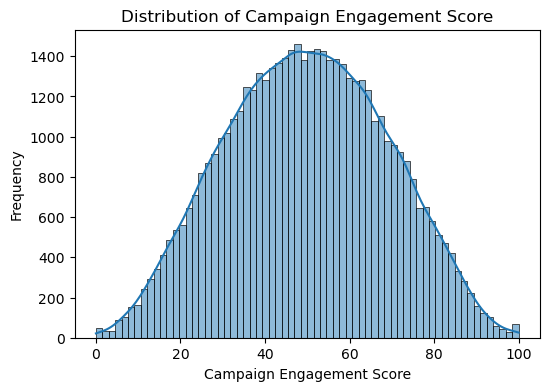

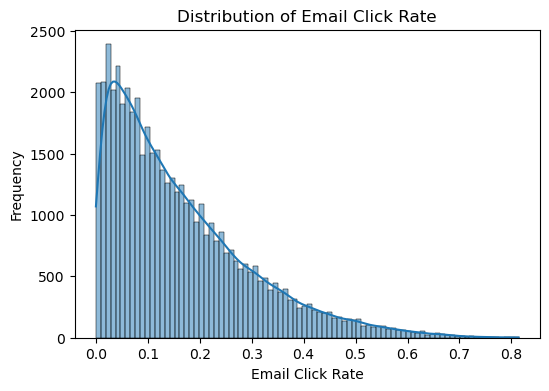

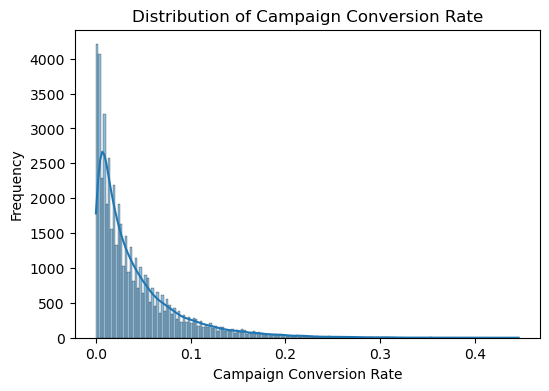

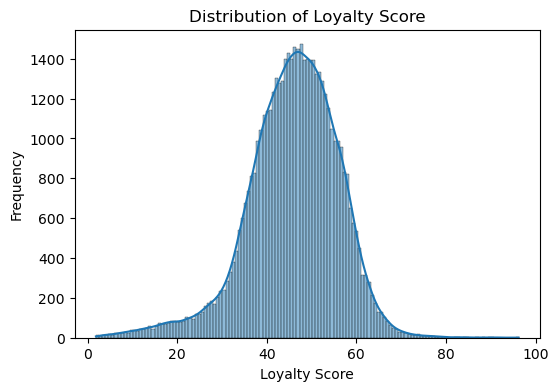

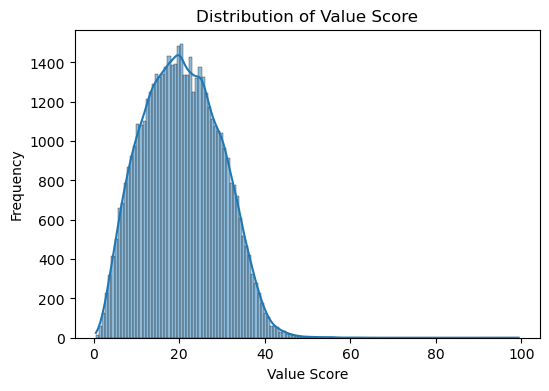

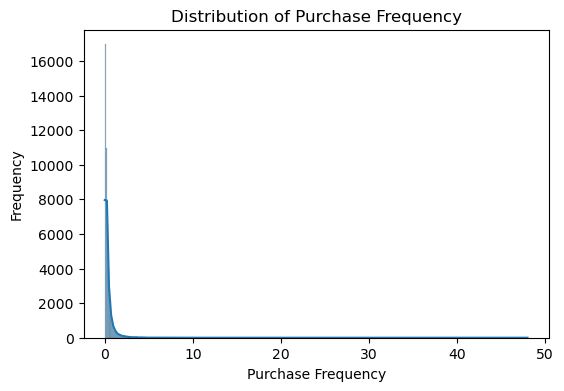

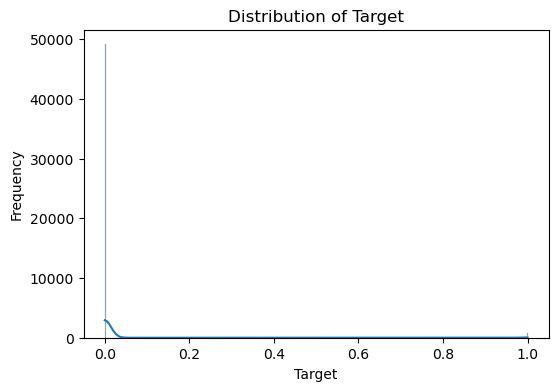

In [10]:
# ===============================
# NUMERICAL FEATURE DISTRIBUTION
# ===============================

for col in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

# Skewness Analysis

This cell calculates the skewness of all numerical features to evaluate the symmetry of their data distribution.

The skewness analysis helps to:

- Measure the degree of skewness for each numerical feature.
- Identify features with highly skewed distributions.
- Support decisions on whether data transformation is required before model training.
- Understand the distribution characteristics that may influence model performance.

In [11]:
# ===============================
# CELL 8: SKEWNESS ANALYSIS
# ===============================

# Numerical features

numerical_features = df.select_dtypes(
    include=["int64","float64"]
).columns


# Calculate skewness

skewness = pd.DataFrame({
    "Feature": numerical_features,
    "Skewness": [
        df[col].skew()
        for col in numerical_features
    ]
})


# Sort by skewness

skewness = skewness.sort_values(
    by="Skewness",
    ascending=False
)


skewness

,Feature,Skewness
15,Purchase Frequency,17.959949
2,Total Spend,10.300001
16,Target,7.399840
5,Last Purchase Days,3.952412
8,Session Count,3.693236
1,Purchase Count,2.496308
12,Campaign Conversion Rate,2.184038
3,Average Order Value,1.687339
6,Tenure Days,1.478436
11,Email Click Rate,1.216218


# Log Transformation

This cell applies a logarithmic (`log1p`) transformation to the numerical features identified as highly skewed during the skewness analysis.

The log transformation helps to:

- Reduce the skewness of numerical features.
- Minimize the impact of extreme values (outliers).
- Create a more balanced feature distribution.
- Improve the learning capability of machine learning models.

**Why Log Transformation?**

The selected features exhibited high positive skewness, which can negatively impact model performance. Applying the `log1p` transformation compresses large values while preserving zero values, resulting in a more normalized distribution and improving the effectiveness of model training.

In [12]:
# ===============================
# CELL 9: LOG TRANSFORMATION
# ===============================

# Features selected based on skewness analysis

skewed_features = [
    "Purchase Frequency",
    "Total Spend",
    "Last Purchase Days",
    "Session Count",
    "Purchase Count",
    "Campaign Conversion Rate",
    "Average Order Value",
    "Tenure Days",
    "Email Click Rate"
]


# Apply log1p transformation

for col in skewed_features:
    
    df[f"log_{col}"] = np.log1p(df[col])


print("Log Transformation Completed")


# Check new columns

df[
    [f"log_{col}" for col in skewed_features]
].head()

Log Transformation Completed


,log_Purchase Frequency,log_Total Spend,log_Last Purchase Days,log_Session Count,log_Purchase Count,log_Campaign Conversion Rate,log_Average Order Value,log_Tenure Days,log_Email Click Rate
0,0.765189,9.725847,2.302585,1.945910,2.397895,0.088011,7.476733,5.568345,0.239804
1,0.067565,6.795840,5.141664,0.693147,0.693147,0.000000,6.826556,6.063785,0.000000
2,0.000000,0.000000,6.527958,1.791759,0.000000,0.012916,0.000000,6.527958,0.070458
3,0.172187,8.835277,3.218876,1.098612,1.386294,0.001000,7.721269,6.173786,0.006976
4,0.200243,7.429058,1.386294,4.025352,1.386294,0.035367,6.363666,6.008813,0.301585


# Evaluate Log Transformation

This cell evaluates the effectiveness of the log transformation by calculating the skewness of the newly transformed features.

The evaluation helps to:

- Measure the skewness of the transformed features.
- Compare the skewness before and after the log transformation.
- Verify whether the transformation has reduced the skewness of the selected features.
- Ensure the transformed features are better suited for machine learning model training.

In [13]:
# ===============================
# CELL 10: CHECK TRANSFORMED SKEWNESS
# ===============================

log_features = [
    f"log_{col}"
    for col in skewed_features
]


transformed_skewness = pd.DataFrame({
    "Feature": log_features,
    "Skewness": [
        df[col].skew()
        for col in log_features
    ]
})


transformed_skewness.sort_values(
    by="Skewness",
    ascending=False
)

,Feature,Skewness
0,log_Purchase Frequency,2.806710
5,log_Campaign Conversion Rate,1.970439
8,log_Email Click Rate,0.944945
2,log_Last Purchase Days,0.931757
3,log_Session Count,-0.092404
4,log_Purchase Count,-0.114852
7,log_Tenure Days,-0.674567
1,log_Total Spend,-1.896899
6,log_Average Order Value,-2.307918


# Distribution Comparison Before and After Log Transformation

This cell compares the distribution of the selected numerical features before and after applying the log transformation.

The comparison helps to:

- Visualize the effect of the log transformation on each feature.
- Compare the original and transformed data distributions side by side.
- Verify that the skewness has been reduced and the feature distribution is more balanced.
- Confirm that the transformed features are better prepared for machine learning model training.

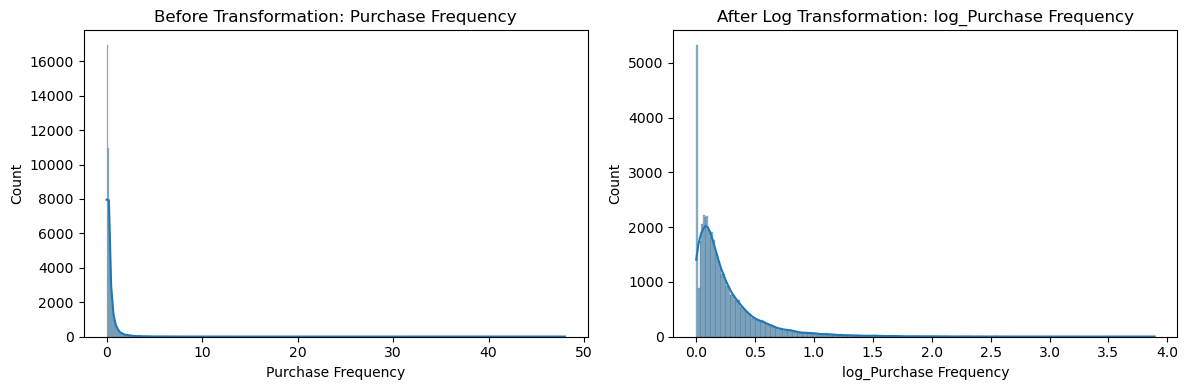

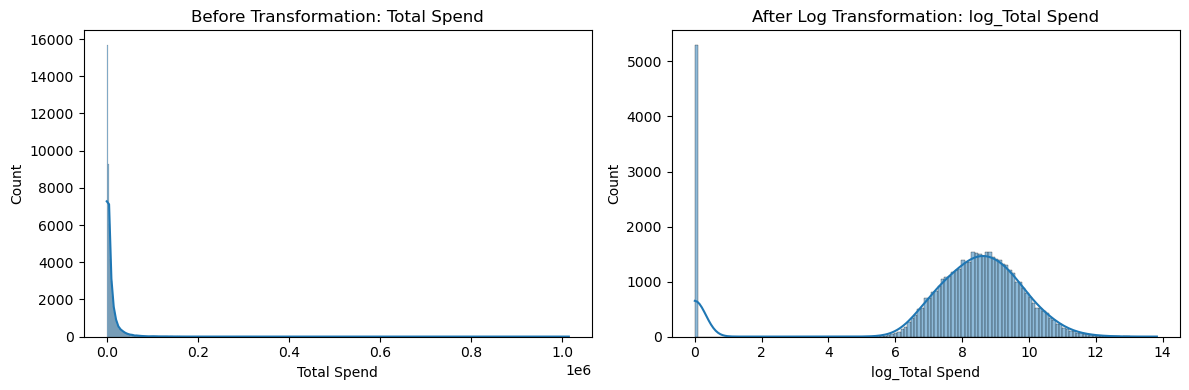

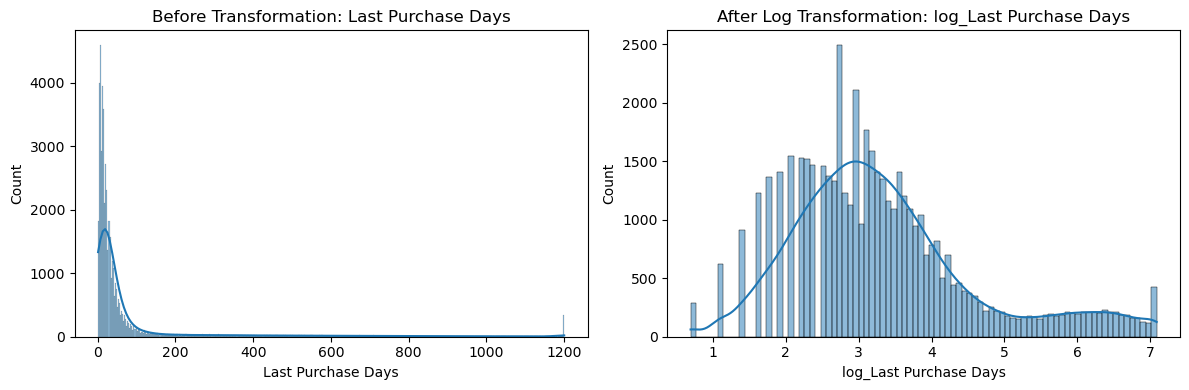

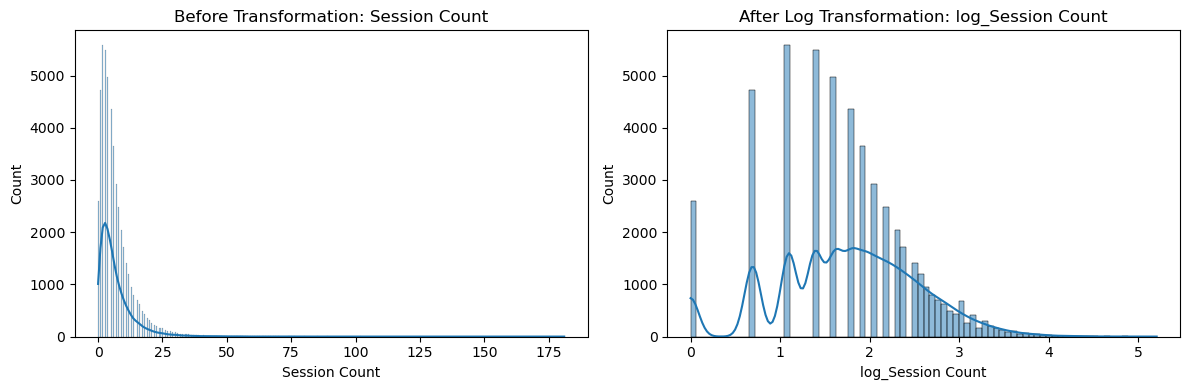

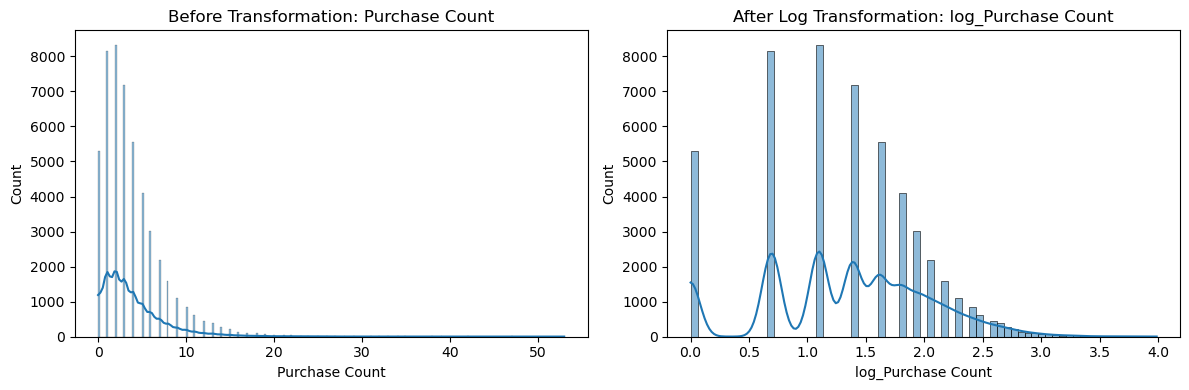

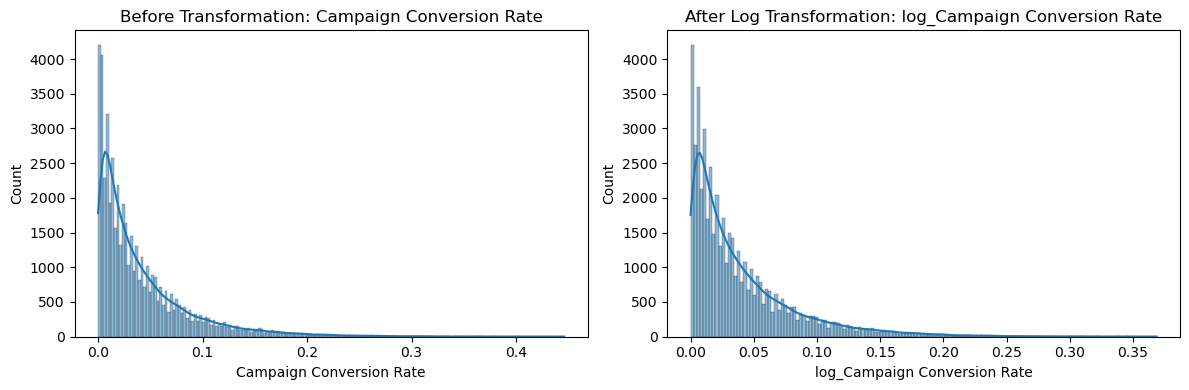

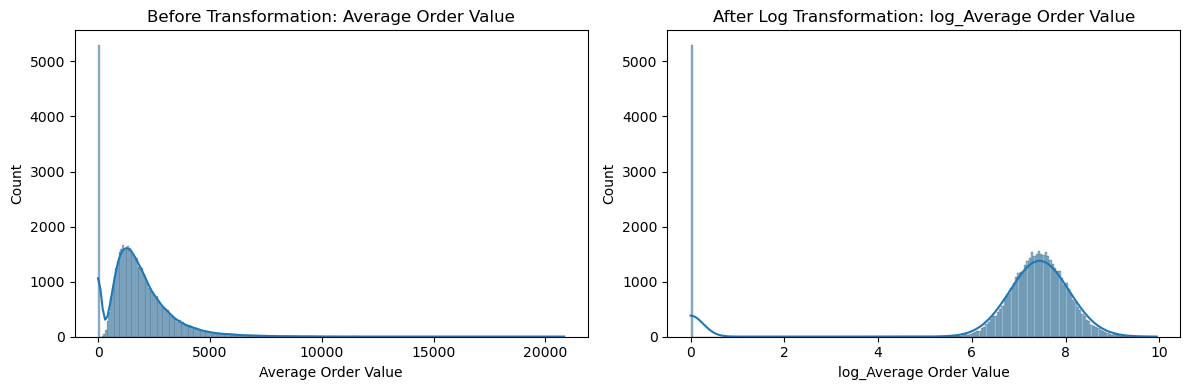

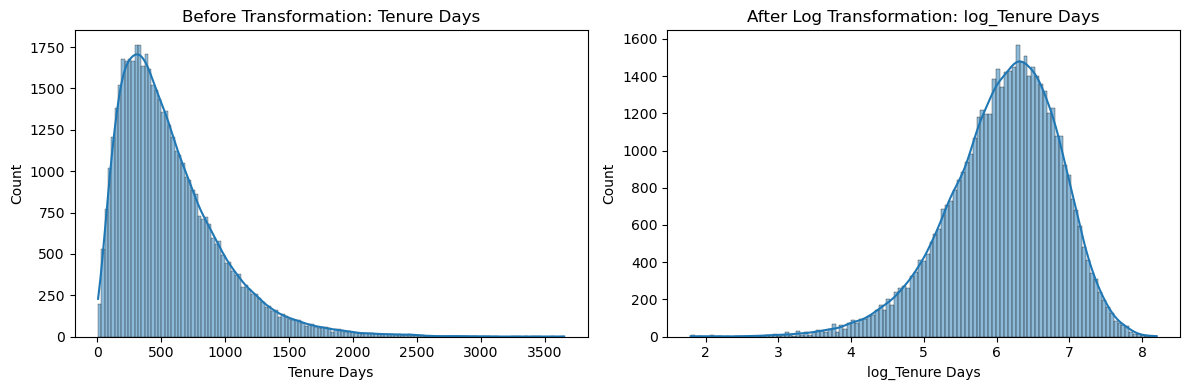

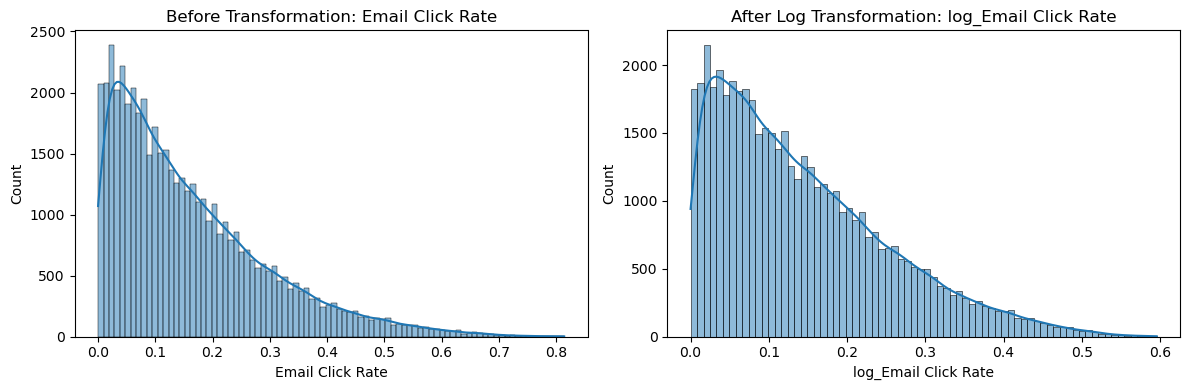

In [14]:
# ===============================
# CELL 10: BEFORE VS AFTER DISTRIBUTION
# ===============================

for col in skewed_features:

    plt.figure(figsize=(12,4))


    # Original distribution
    plt.subplot(1,2,1)

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(
        f"Before Transformation: {col}"
    )


    # Log transformed distribution
    plt.subplot(1,2,2)

    sns.histplot(
        df[f"log_{col}"],
        kde=True
    )

    plt.title(
        f"After Log Transformation: log_{col}"
    )


    plt.tight_layout()

    plt.show()

# Outlier Analysis

This cell analyzes the numerical features for potential outliers by visualizing each feature using boxplots.

The outlier analysis helps to:

- Identify potential outliers in each numerical feature.
- Understand the spread and variability of the data.
- Detect extreme values that may influence model performance.
- Support decisions on whether outlier treatment is required during data preprocessing.

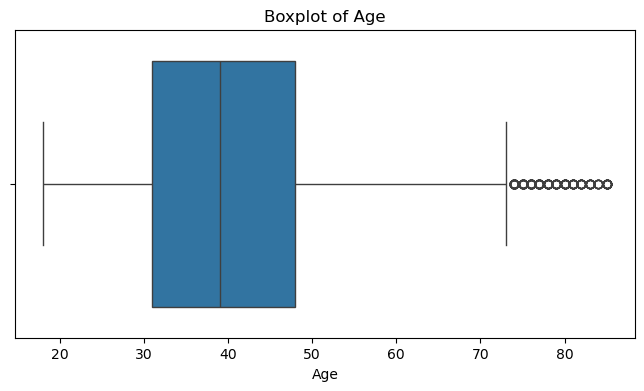

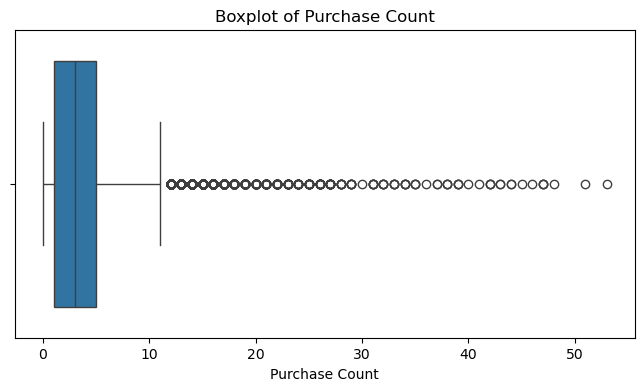

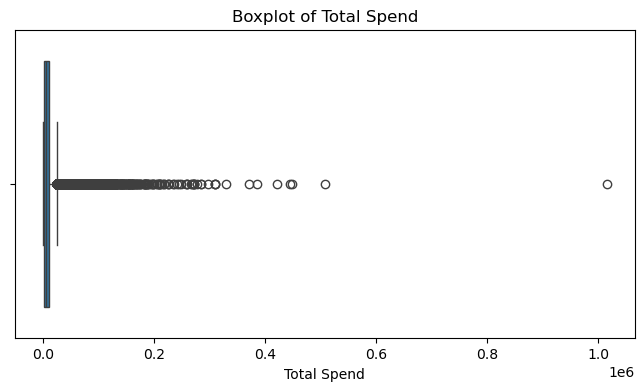

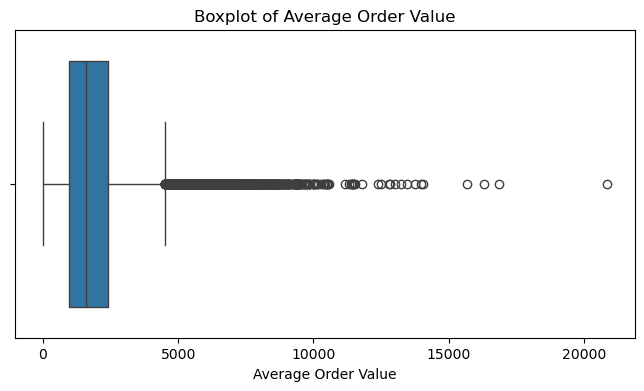

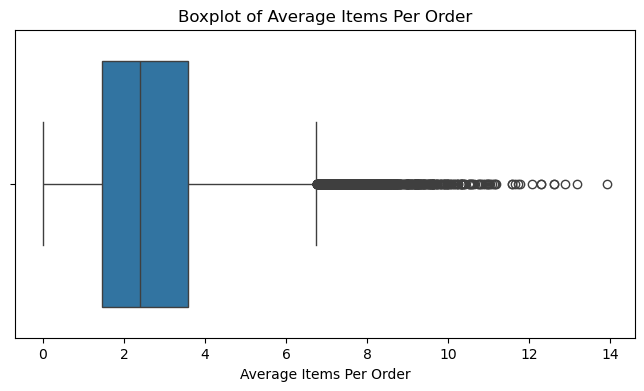

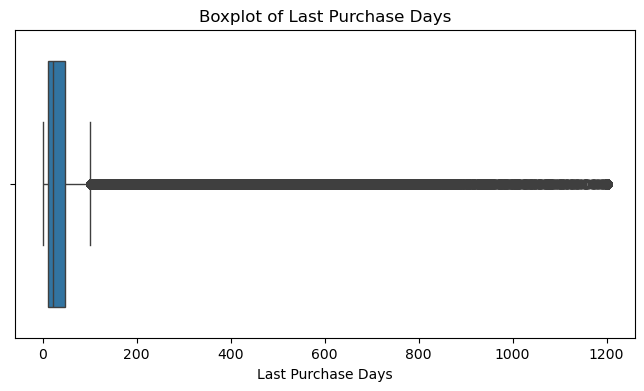

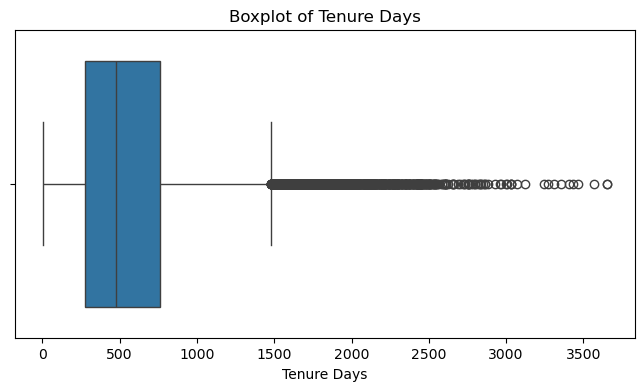

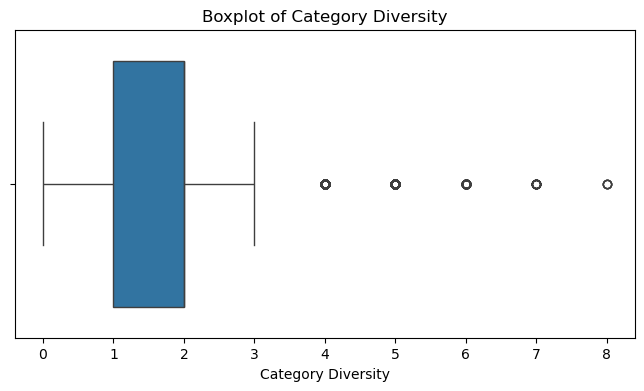

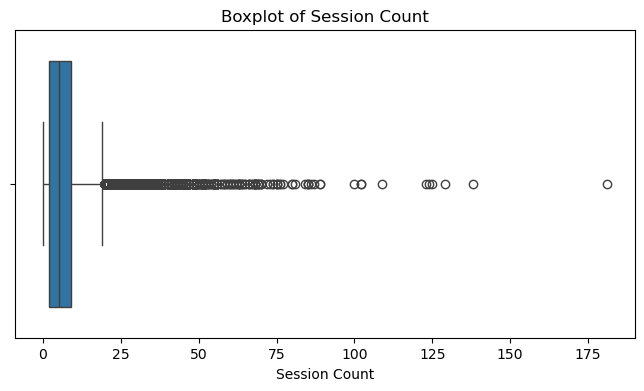

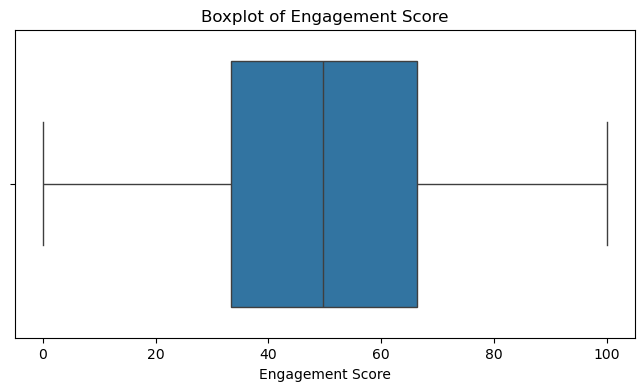

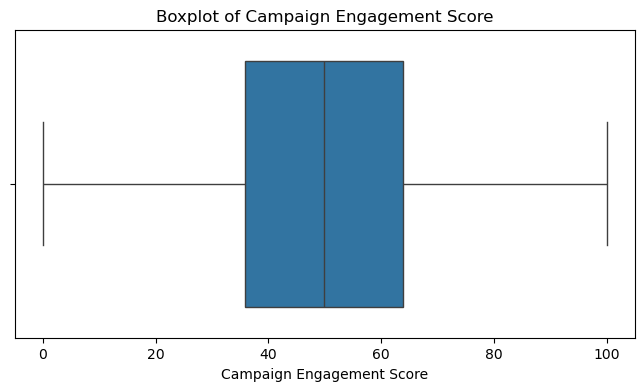

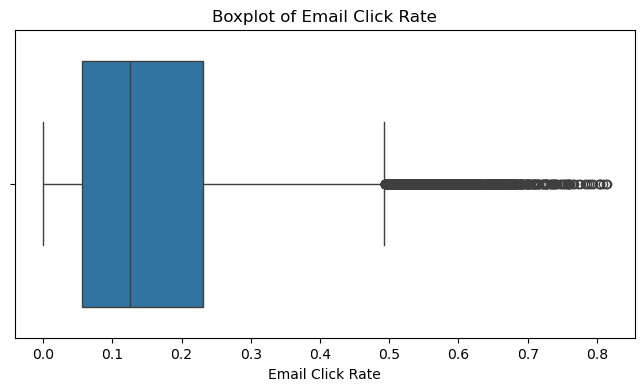

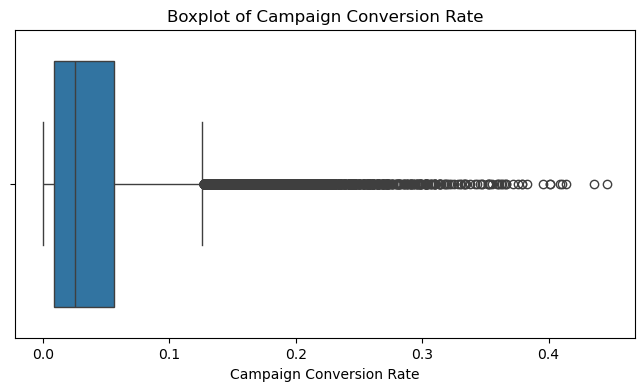

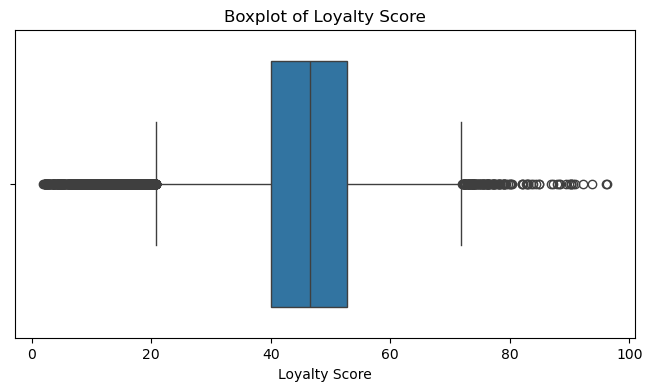

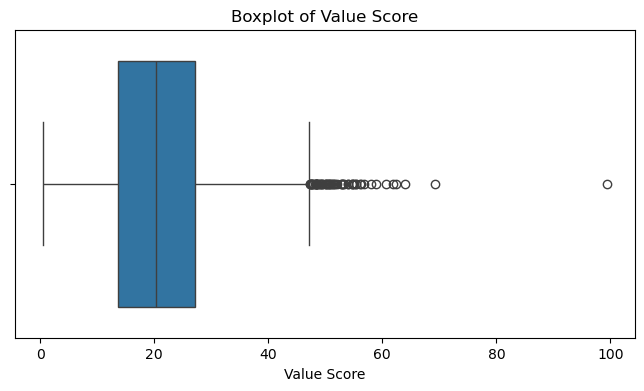

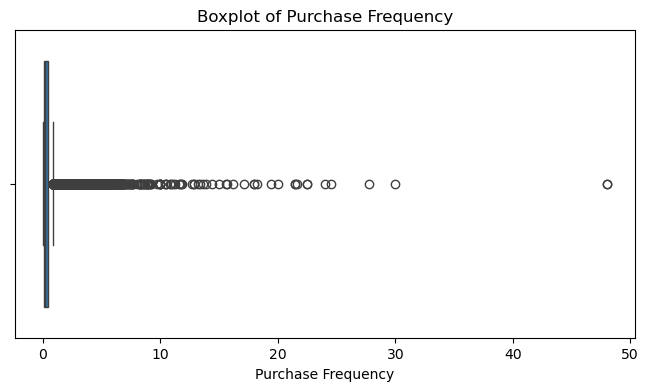

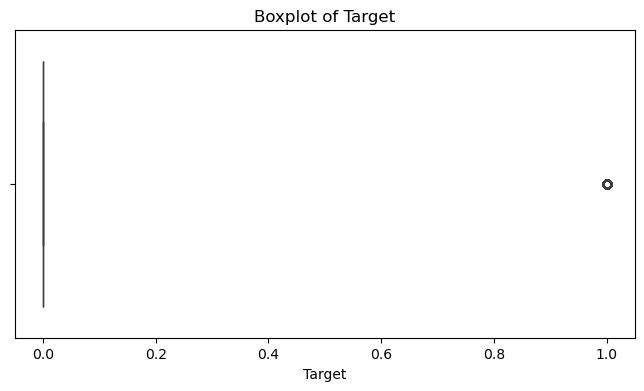

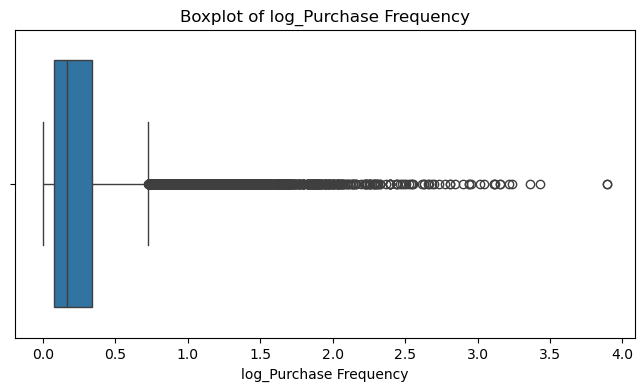

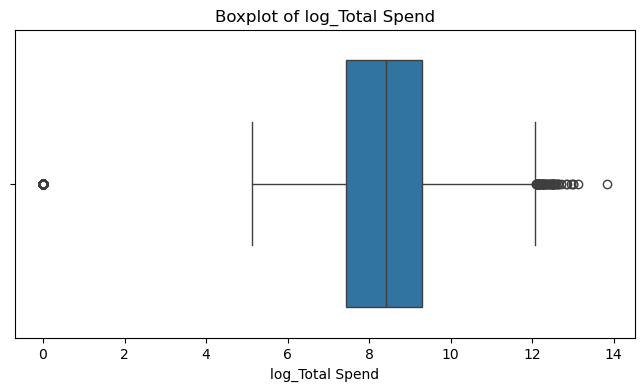

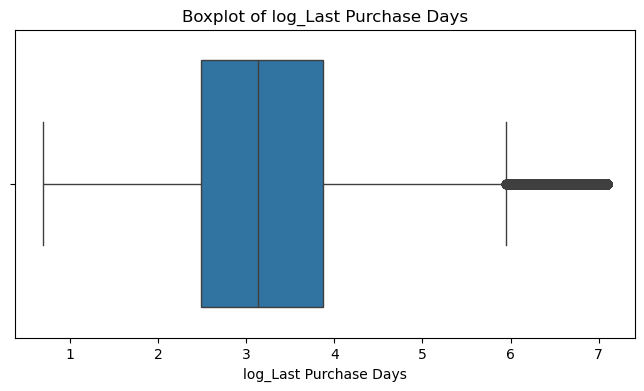

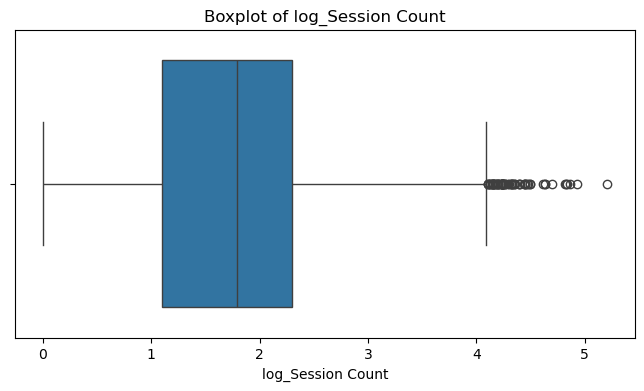

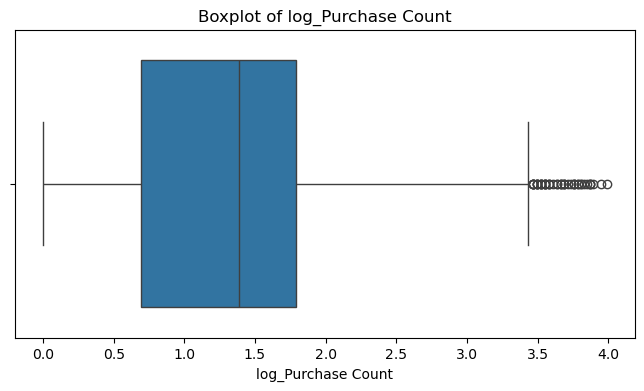

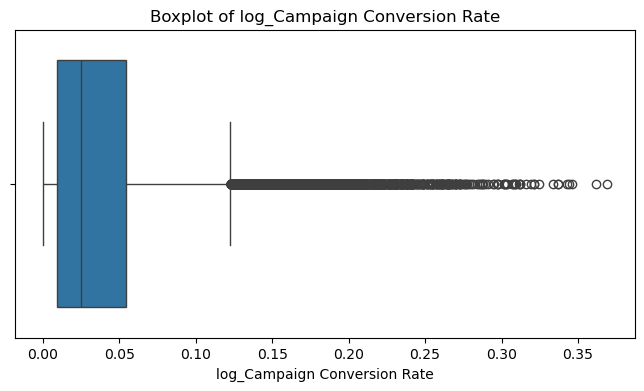

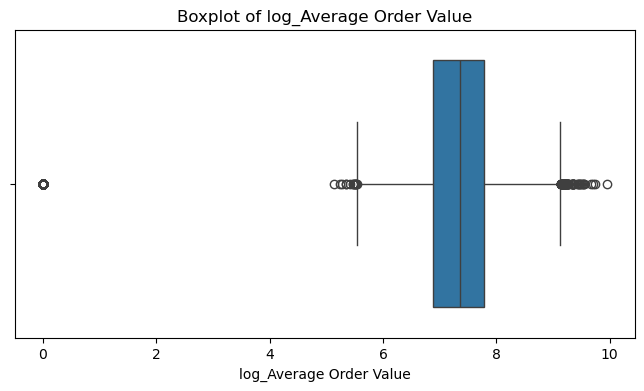

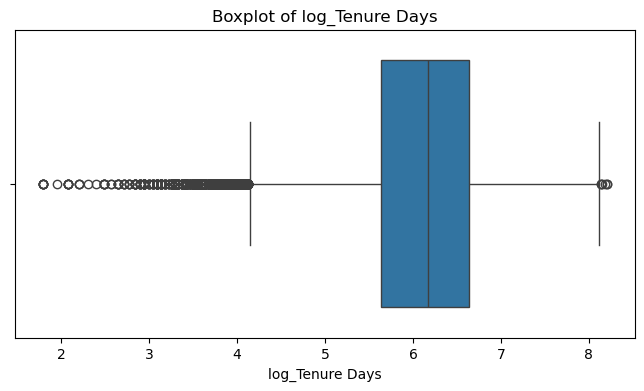

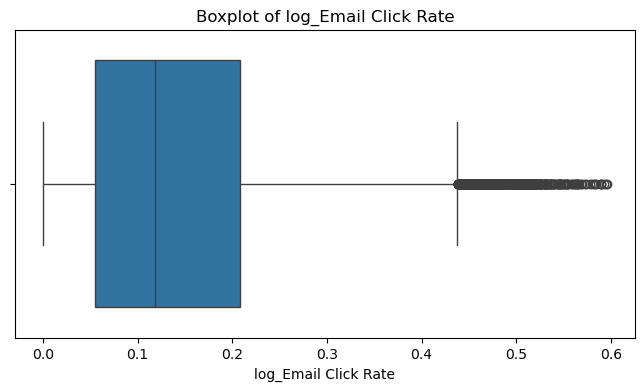

In [15]:
# ===============================
# CELL 11: OUTLIER ANALYSIS
# ===============================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()

# Outlier Detection Using IQR

This cell identifies and summarizes outliers in each numerical feature using the Interquartile Range (IQR) method.

The outlier analysis helps to:

- Calculate the number of outliers present in each numerical feature.
- Determine the percentage of outliers relative to the total number of records.
- Identify features that contain a high proportion of extreme values.
- Support decisions on whether outlier treatment is required before model training.

**Why IQR Method?**

The IQR method is a widely used statistical technique for detecting outliers. It identifies observations that fall significantly below or above the normal range of the data, making it suitable for numerical features with skewed distributions and less sensitive to extreme values than methods based on the mean and standard deviation.

In [16]:
# ===============================
# OUTLIER COUNT USING IQR
# ===============================

outlier_summary = []

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outliers,
        "Outlier Percentage": round((outliers / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outlier Percentage",
    ascending=False
)

,Feature,Outlier Count,Outlier Percentage
5,Last Purchase Days,6559,13.12
23,log_Average Order Value,5392,10.78
18,log_Total Spend,5361,10.72
2,Total Spend,4391,8.78
15,Purchase Frequency,4301,8.60
17,log_Purchase Frequency,3180,6.36
19,log_Last Purchase Days,3097,6.19
12,Campaign Conversion Rate,2939,5.88
22,log_Campaign Conversion Rate,2733,5.47
8,Session Count,2503,5.01


# Handle Missing Values

This cell handles the missing values in both numerical and categorical features to ensure the dataset is complete before model training.

The preprocessing includes:

- Replacing missing values in numerical features using the **median**.
- Replacing missing values in categorical features using the **mode**.
- Verifying that all missing values have been successfully handled.

**Why Median for Numerical Features?**

The median is less sensitive to extreme values and outliers than the mean, making it a more reliable choice for imputing missing values in numerical data with skewed distributions.

**Why Mode for Categorical Features?**

The mode replaces missing values with the most frequently occurring category, preserving the original distribution of categorical features without introducing new categories or removing valuable records.

In [17]:
# ===============================
# CELL 12: HANDLE MISSING VALUES
# ===============================

# Numerical columns
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_features = df.select_dtypes(include=["object"]).columns


# Fill numerical missing values with median
for col in numerical_features:
    df[col].fillna(df[col].median(), inplace=True)


# Fill categorical missing values with mode
for col in categorical_features:
    df[col].fillna(df[col].mode()[0], inplace=True)


print("Missing values handled successfully!")

# Verify
print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

Missing values handled successfully!

Remaining Missing Values:
0


# Categorical Feature Analysis

This cell analyzes all categorical features in the dataset to understand their characteristics and value distribution.

The analysis includes:

- Identifying all categorical features in the dataset.
- Displaying the total number of categorical features.
- Calculating the number of unique categories for each feature.
- Displaying the most frequently occurring categories and their respective counts.

**Why Categorical Feature Analysis?**

Understanding categorical features helps identify the diversity and distribution of categories within the dataset. This analysis supports feature engineering, encoding decisions, and helps detect features with high cardinality or imbalanced category distributions before model training.

In [18]:
# ===============================
# CELL 13: CATEGORICAL FEATURE ANALYSIS
# ===============================

# Select categorical columns
categorical_features = df.select_dtypes(include=["object"]).columns

print(f"Number of Categorical Features: {len(categorical_features)}\n")

for col in categorical_features:

    print("=" * 60)
    print(f"Feature : {col}")
    print(f"Unique Values : {df[col].nunique()}")
    print(f"Top Categories:\n")
    print(df[col].value_counts().head(10))
    print("\n")

Number of Categorical Features: 4

Feature : Gender
Unique Values : 3
Top Categories:

Gender
Female    25246
Male      23273
Other      1481
Name: count, dtype: int64


Feature : Region / State
Unique Values : 5
Top Categories:

Region / State
South      12213
North      10935
West       10063
East        8927
Central     7862
Name: count, dtype: int64


Feature : Preferred Category
Unique Values : 8
Top Categories:

Preferred Category
Fashion        14180
Electronics     7201
Grocery         6640
Home            6290
Beauty          5333
Sports          4080
Books           3582
Toys            2694
Name: count, dtype: int64


Feature : Preferred Channel
Unique Values : 5
Top Categories:

Preferred Channel
Email       17087
Push        10839
WhatsApp     9206
SMS          8947
Call         3921
Name: count, dtype: int64




# Categorical Feature Visualization

This cell visualizes the distribution of the top 10 most frequent categories for each categorical feature using bar charts.

The visualization helps to:

- Compare the frequency of different categories within each feature.
- Identify the most common categories in the dataset.
- Detect category imbalance and dominant categories.
- Support feature engineering and categorical encoding decisions before model training.

**Why Visualize Categorical Features?**

Visualizing categorical features provides a clear understanding of category distributions and helps identify imbalanced or dominant categories that may influence model performance. These insights are valuable when selecting appropriate encoding techniques and preparing the data for machine learning.

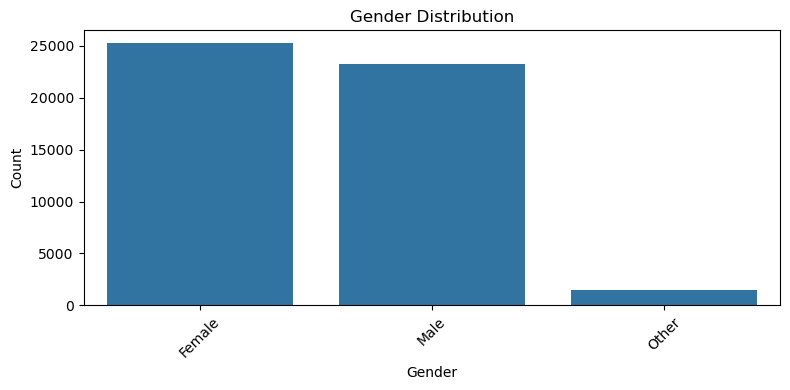

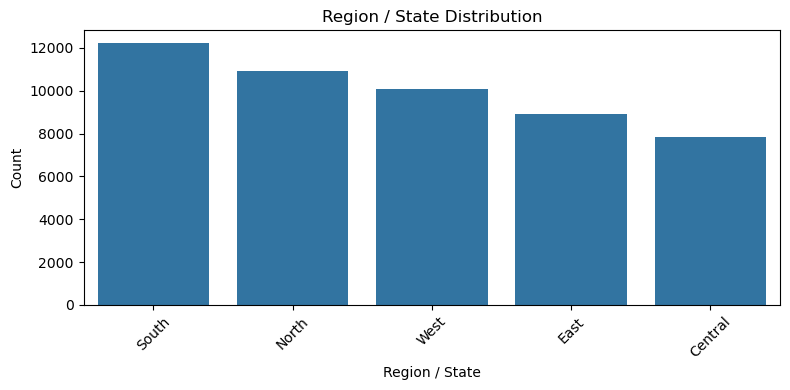

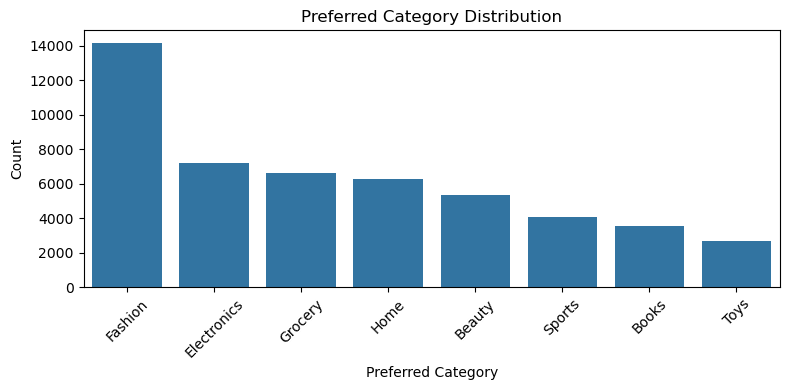

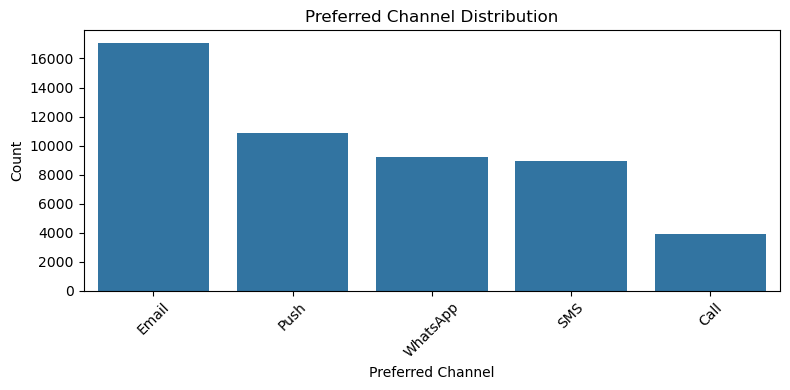

In [19]:
# ===============================
# CELL 14: CATEGORICAL VISUALIZATION
# ===============================

for col in categorical_features:

    plt.figure(figsize=(8,4))

    top_categories = df[col].value_counts().head(10)

    sns.barplot(
        x=top_categories.index,
        y=top_categories.values
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# One-Hot Encoding

This cell converts all categorical features into numerical format using One-Hot Encoding, making them suitable for machine learning model training.

The preprocessing includes:

- Identifying all categorical features in the dataset.
- Converting each categorical feature into binary (0 and 1) columns using One-Hot Encoding.
- Removing one dummy variable from each feature (`drop_first=True`) to avoid multicollinearity.
- Displaying the updated dataset shape after encoding.

**Why One-Hot Encoding?**

Machine learning algorithms cannot directly process categorical (text) data. One-Hot Encoding converts categorical values into numerical binary features while preserving the information contained in each category. Using `drop_first=True` reduces redundant features and helps prevent multicollinearity, resulting in a more efficient and stable machine learning model.

In [20]:
# ===============================
# CELL 15: ONE-HOT ENCODING
# ===============================

# Identify categorical columns

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

# Apply One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\nEncoding Completed Successfully!")

print("\nNew Dataset Shape:")
print(df.shape)

df.head()

Categorical Features:
['Gender', 'Region / State', 'Preferred Category', 'Preferred Channel']

Encoding Completed Successfully!

New Dataset Shape:
(50000, 43)


,Age,Purchase Count,Total Spend,Average Order Value,Average Items Per Order,Last Purchase Days,Tenure Days,Category Diversity,Session Count,Engagement Score,...,Preferred Category_Electronics,Preferred Category_Fashion,Preferred Category_Grocery,Preferred Category_Home,Preferred Category_Sports,Preferred Category_Toys,Preferred Channel_Email,Preferred Channel_Push,Preferred Channel_SMS,Preferred Channel_WhatsApp
0,26.0,10,16743.86,1765.46,4.52,9,261,4,6,65.19,...,1,0,0,0,0,0,0,0,0,1
1,69.0,1,893.12,921.01,2.22,170,429,1,1,5.52,...,0,0,0,0,1,0,0,1,0,0
2,30.0,0,0.00,0.00,0.00,683,683,0,5,47.75,...,0,1,0,0,0,0,1,0,0,0
3,18.0,3,6871.46,2254.82,1.73,24,479,2,2,25.58,...,0,0,0,1,0,0,0,0,0,1
4,47.0,3,1683.22,579.37,1.17,3,406,2,55,86.81,...,1,0,0,0,0,0,1,0,0,0


# Verify Encoded Features

This cell displays the updated list of dataset columns after applying One-Hot Encoding.

The verification helps to:

- Confirm that categorical features have been successfully converted into numerical features.
- Verify the newly created encoded columns.
- Ensure the dataset is ready for feature selection and machine learning model development.

In [21]:
print(df.columns.tolist())

['Age', 'Purchase Count', 'Total Spend', 'Average Order Value', 'Average Items Per Order', 'Last Purchase Days', 'Tenure Days', 'Category Diversity', 'Session Count', 'Engagement Score', 'Campaign Engagement Score', 'Email Click Rate', 'Campaign Conversion Rate', 'Loyalty Score', 'Value Score', 'Purchase Frequency', 'Target', 'log_Purchase Frequency', 'log_Total Spend', 'log_Last Purchase Days', 'log_Session Count', 'log_Purchase Count', 'log_Campaign Conversion Rate', 'log_Average Order Value', 'log_Tenure Days', 'log_Email Click Rate', 'Gender_Male', 'Gender_Other', 'Region / State_East', 'Region / State_North', 'Region / State_South', 'Region / State_West', 'Preferred Category_Books', 'Preferred Category_Electronics', 'Preferred Category_Fashion', 'Preferred Category_Grocery', 'Preferred Category_Home', 'Preferred Category_Sports', 'Preferred Category_Toys', 'Preferred Channel_Email', 'Preferred Channel_Push', 'Preferred Channel_SMS', 'Preferred Channel_WhatsApp']


# Target Variable Identification

This cell identifies the target variable required for the Product Affinity Prediction model.

The process includes:

- Checking whether a target variable already exists in the dataset.
- Searching for commonly used target column names.
- Creating a new target variable using predefined business rules if no target column is available.
- Displaying the distribution of the target classes to understand the balance between positive and negative samples.

**Why Create the Target Variable?**

Since the original dataset does not contain a predefined target variable, a new target is generated using business rules based on customer purchasing behavior. Customers with higher purchase frequency, higher engagement, higher spending, and more recent purchases are classified as having a higher product affinity. This creates a meaningful target variable that enables the machine learning models to learn customer purchasing patterns and predict product affinity.

In [22]:
# ===============================
# CELL 16: TARGET VARIABLE CHECK
# ===============================

# Possible target column names

possible_targets = [
    "Target",
    "target",
    "Purchase_Flag",
    "Purchase Flag",
    "Affinity",
    "Product Affinity",
    "Purchased",
    "Response"
]

target_column = None

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

# -------------------------------
# Case 1 : Target already exists
# -------------------------------

if target_column is not None:

    print(f"Existing Target Found: {target_column}")

# -------------------------------
# Case 2 : Create Target
# -------------------------------

else:

    print("No target column found.")
    print("Creating target using business rules...")

    df["Target"] = (
        (
            (df["Purchase Frequency"] >= df["Purchase Frequency"].median()) &
            (df["Engagement Score"] >= df["Engagement Score"].median()) &
            (df["Total Spend"] >= df["Total Spend"].median()) &
            (df["Last Purchase Days"] <= df["Last Purchase Days"].median())
        )
    ).astype(int)

    target_column = "Target"

print("\nTarget Distribution:")
print(df[target_column].value_counts())

Existing Target Found: Target

Target Distribution:
Target
0    49134
1      866
Name: count, dtype: int64


# Define Features and Target Variable

This cell separates the dataset into the feature matrix (`X`) and the target variable (`y`) for machine learning model development.

The process includes:

- Defining the input features by removing the target column from the dataset.
- Defining the target variable that the model will learn to predict.
- Displaying the shape of the feature matrix and target variable.
- Verifying the distribution of the target classes.

**Why Separate Features and Target?**

Machine learning models require the input features (`X`) and the target variable (`y`) to be defined separately. The model uses the features to learn patterns and relationships in the data, while the target variable represents the outcome that the model is trained to predict.

In [23]:
# ===============================
# CELL 17: DEFINE FEATURES & TARGET
# ===============================

X = df.drop(columns=[target_column])

y = df[target_column]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape : (50000, 42)
Target Shape : (50000,)

Target Distribution:
Target
0    49134
1      866
Name: count, dtype: int64


# Train-Test Split

This cell splits the dataset into training and testing sets to evaluate the machine learning models on unseen data.

The process includes:

- Splitting the dataset into **80% training data** and **20% testing data**.
- Using a fixed `random_state` to ensure reproducible results.
- Applying stratified sampling to maintain the same target class distribution in both training and testing datasets.
- Displaying the shapes and target distribution of the training and testing datasets.

**Why Train-Test Split?**

The train-test split allows the model to learn patterns from the training dataset while evaluating its performance on unseen testing data. Using an **80:20 split** provides sufficient data for model training while reserving an independent dataset for performance evaluation.

**Why Stratified Sampling?**

Stratified sampling (`stratify=y`) preserves the original class distribution in both the training and testing datasets. This ensures that both datasets represent the target variable fairly, leading to more reliable and unbiased model evaluation.

In [24]:
# ===============================
# CELL 18: TRAIN TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Shape : (40000, 42)
Testing Shape  : (10000, 42)

Training Target Distribution:
Target
0    39307
1      693
Name: count, dtype: int64

Testing Target Distribution:
Target
0    9827
1     173
Name: count, dtype: int64


# Feature Scaling

This cell standardizes the numerical features using the **StandardScaler** to ensure that all features are on a similar scale before model training.

The preprocessing includes:

- Initializing the `StandardScaler`.
- Fitting the scaler using only the training dataset.
- Transforming both the training and testing datasets using the fitted scaler.
- Displaying the shape of the scaled training and testing datasets.

**Why StandardScaler?**

Machine learning algorithms perform better when numerical features have a similar scale. StandardScaler transforms the data by centering each feature around a mean of 0 and scaling it to have a standard deviation of 1. This prevents features with larger values from having a disproportionate influence on the model.

**Why Fit Only on the Training Data?**

The scaler is fitted only on the training dataset to prevent **data leakage**. The same scaling parameters are then applied to the testing dataset, ensuring that the model is evaluated on unseen data under real-world conditions.

In [25]:
# ===============================
# CELL 19: FEATURE SCALING
# ===============================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale only the training data, then transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed!
Scaled Training Shape : (40000, 42)
Scaled Testing Shape  : (10000, 42)


# Feature Selection

This cell selects the most relevant features for model training using the **SelectKBest** feature selection technique with **Mutual Information** as the scoring method.

The feature selection process includes:

- Selecting the top **20** most informative features from the dataset.
- Fitting the feature selector using only the training dataset.
- Transforming both the training and testing datasets using the selected features.
- Displaying the names of the selected features and the updated dataset dimensions.

**Why Feature Selection?**

Feature selection helps eliminate less relevant or redundant features, reducing the complexity of the model. By retaining only the most informative features, the model can train more efficiently, reduce the risk of overfitting, and improve overall prediction performance.

**Why SelectKBest with Mutual Information?**

`SelectKBest` ranks features based on their relationship with the target variable and selects the highest-scoring features. **Mutual Information** measures both linear and non-linear dependencies between features and the target, making it well-suited for Product Affinity Prediction, where customer behavior may involve complex relationships that traditional correlation methods may not capture.

In [26]:
# ===============================
# CELL 20: FEATURE SELECTION
# ===============================

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select the top 20 features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

# Fit on training data only
X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

# Transform test data
X_test_selected = selector.transform(
    X_test
)

# Selected feature names
selected_features = X_train.columns[
    selector.get_support()
]

print("Selected Features:\n")
print(selected_features.tolist())

print("\nTraining Shape:", X_train_selected.shape)
print("Testing Shape :", X_test_selected.shape)

Selected Features:

['Purchase Count', 'Total Spend', 'Average Order Value', 'Last Purchase Days', 'Category Diversity', 'Session Count', 'Engagement Score', 'Campaign Engagement Score', 'Email Click Rate', 'Campaign Conversion Rate', 'Loyalty Score', 'Value Score', 'Purchase Frequency', 'log_Purchase Frequency', 'log_Total Spend', 'log_Session Count', 'log_Purchase Count', 'log_Campaign Conversion Rate', 'log_Average Order Value', 'log_Email Click Rate']

Training Shape: (40000, 20)
Testing Shape : (10000, 20)


# Logistic Regression Model

This cell trains and evaluates a **Logistic Regression** model for Product Affinity Prediction.

The model development process includes:

- Initializing the Logistic Regression model with predefined parameters.
- Training the model using the scaled training dataset.
- Predicting the target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, Classification Report, and Confusion Matrix.

**Why Logistic Regression?**

Logistic Regression is a widely used baseline classification algorithm that predicts the probability of a customer belonging to a particular class. It is simple, computationally efficient, and provides a strong benchmark for comparing the performance of more advanced machine learning models.

**Why These Evaluation Metrics?**

- **Accuracy** measures the overall percentage of correctly classified records.
- **Precision** evaluates how many predicted positive cases are actually positive.
- **Recall** measures the model's ability to correctly identify actual positive cases.
- **F1-Score** provides a balanced measure by combining Precision and Recall.
- **ROC-AUC** evaluates the model's ability to distinguish between the target classes across different decision thresholds.
- **Classification Report** provides a detailed summary of the model's performance for each class.
- **Confusion Matrix** shows the number of correct and incorrect predictions, helping to identify the types of classification errors made by the model.

In [27]:
# ===============================
# CELL 21: LOGISTIC REGRESSION
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Initialize model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_model.predict(X_test_scaled)

# Prediction probabilities
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.9980
Precision: 0.9581
Recall   : 0.9249
F1 Score : 0.9412
ROC AUC  : 0.9998

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.96      0.92      0.94       173

    accuracy                           1.00     10000
   macro avg       0.98      0.96      0.97     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix
[[9820    7]
 [  13  160]]


# Logistic Regression Confusion Matrix

This cell visualizes the performance of the Logistic Regression model using a confusion matrix heatmap.

The visualization helps to:

- Display the number of correctly and incorrectly classified observations.
- Compare the actual and predicted class labels.
- Identify the types of classification errors made by the model.
- Provide a visual summary of the model's classification performance.

**Why Use a Confusion Matrix?**

A confusion matrix provides a detailed breakdown of prediction results, allowing us to evaluate not only the overall accuracy but also the number of true positives, true negatives, false positives, and false negatives. This helps in understanding the strengths and weaknesses of the classification model.

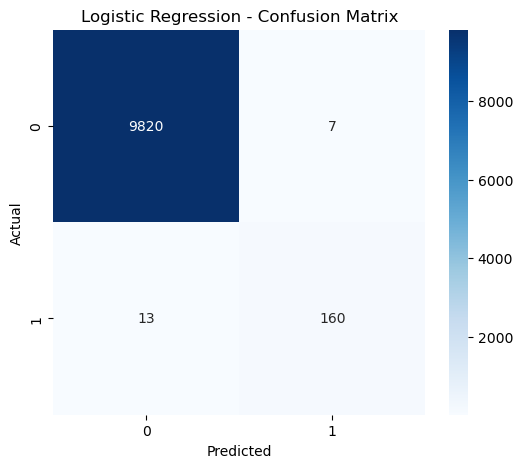

In [28]:
# ===============================
# CELL 22: CONFUSION MATRIX
# ===============================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Classifier

This cell trains and evaluates a **Random Forest Classifier** for Product Affinity Prediction.

The model development process includes:

- Initializing the Random Forest model with predefined hyperparameters.
- Training the model using the training dataset.
- Predicting the target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Classification Report.

**Why Random Forest?**

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It can effectively capture complex relationships between customer attributes and purchasing behavior, making it well-suited for Product Affinity Prediction. Additionally, Random Forest is robust to noise, handles high-dimensional data efficiently, and provides stable predictions across diverse datasets.

In [29]:
# ===============================
# CELL 23: RANDOM FOREST
# ===============================

from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy : 0.9946
Precision: 0.9407
Recall   : 0.7341
F1 Score : 0.8247
ROC AUC  : 0.9988

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.94      0.73      0.82       173

    accuracy                           0.99     10000
   macro avg       0.97      0.87      0.91     10000
weighted avg       0.99      0.99      0.99     10000



# Random Forest Confusion Matrix

This cell visualizes the performance of the Random Forest model using a confusion matrix heatmap.

The visualization helps to:

- Display the number of correctly and incorrectly classified observations.
- Compare the actual and predicted class labels.
- Identify the types of classification errors made by the model.
- Assess the classification performance of the Random Forest model.

**Why Use a Confusion Matrix?**

A confusion matrix provides a detailed summary of the model's predictions by showing the number of true positives, true negatives, false positives, and false negatives. This helps evaluate how effectively the Random Forest model distinguishes between the target classes and highlights areas where misclassifications occur.

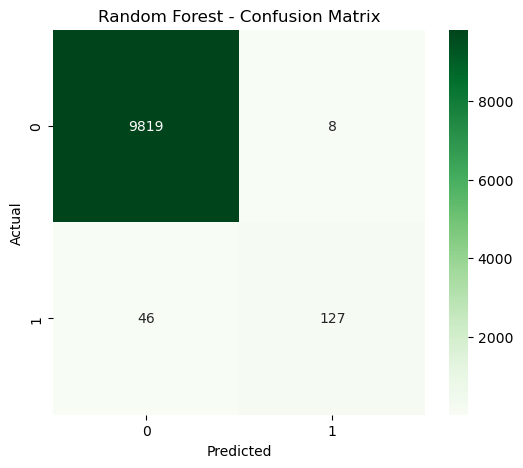

In [30]:
# ===============================
# CELL 24: RANDOM FOREST CONFUSION MATRIX
# ===============================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Gradient Boosting Classifier

This cell trains and evaluates a **Gradient Boosting Classifier** for Product Affinity Prediction.

The model development process includes:

- Initializing the Gradient Boosting model with predefined hyperparameters.
- Training the model using the training dataset.
- Predicting the target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Classification Report.

**Why Gradient Boosting?**

Gradient Boosting is an ensemble learning algorithm that builds multiple decision trees sequentially, where each new tree focuses on correcting the errors made by previous trees. This improves the overall predictive performance of the model.

For Product Affinity Prediction, customer purchase behavior depends on complex relationships between multiple factors such as customer demographics, purchasing patterns, engagement activities, and transaction history. Gradient Boosting can effectively capture these non-linear relationships and feature interactions.

The model is also capable of handling complex datasets, reducing prediction errors through iterative learning, and producing accurate probability-based predictions, making it suitable for identifying customer product preferences and affinity patterns.

In [31]:
# ===============================
# CELL 26: GRADIENT BOOSTING
# ===============================

from sklearn.ensemble import GradientBoostingClassifier

# Initialize model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print("=" * 50)
print("GRADIENT BOOSTING RESULTS")
print("=" * 50)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC AUC  : {gb_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING RESULTS
Accuracy : 0.9962
Precision: 0.9470
Recall   : 0.8266
F1 Score : 0.8827
ROC AUC  : 0.9964

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.95      0.83      0.88       173

    accuracy                           1.00     10000
   macro avg       0.97      0.91      0.94     10000
weighted avg       1.00      1.00      1.00     10000



# Gradient Boosting Classifier - Confusion Matrix

This cell generates and visualizes the **Confusion Matrix** for the Gradient Boosting Classifier model.

The confusion matrix helps to understand how well the model is classifying the target classes by comparing the actual values with the predicted values.

The evaluation process includes:

- Generating the confusion matrix using actual test labels (`y_test`) and predicted labels (`y_pred_gb`).
- Displaying the confusion matrix as a heatmap for better visualization.
- Analyzing correct and incorrect predictions made by the Gradient Boosting model.

---

## Why Confusion Matrix?

Accuracy alone does not explain the complete model performance. The confusion matrix provides detailed information about prediction outcomes.

It separates predictions into four categories:

- **True Positive (TP):**  
  The model correctly predicts the positive class.

- **True Negative (TN):**  
  The model correctly predicts the negative class.

- **False Positive (FP):**  
  The model incorrectly predicts the positive class when the actual class is negative.

- **False Negative (FN):**  
  The model incorrectly predicts the negative class when the actual class is positive.

---

## Operation Performed

```python
confusion_matrix(y_test, y_pred_gb)

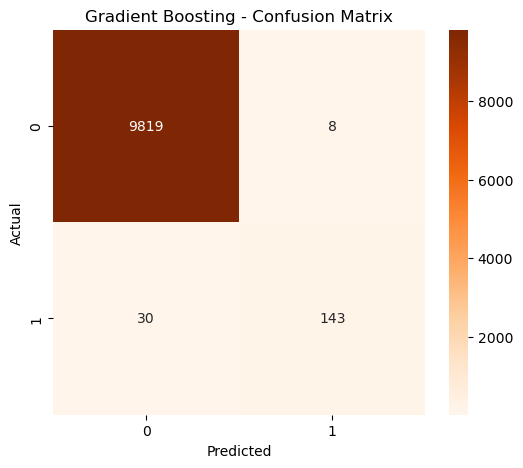

In [32]:
# ===============================
# CELL 27: GRADIENT BOOSTING
# CONFUSION MATRIX
# ===============================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_gb),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Gradient Boosting - Feature Importance Analysis

This cell performs **Feature Importance Analysis** for the trained Gradient Boosting Classifier model.

The purpose of this step is to identify which customer features contribute the most towards the model's prediction decisions.

The analysis process includes:

- Extracting feature importance values from the trained Gradient Boosting model.
- Creating a DataFrame containing feature names and their importance scores.
- Sorting features based on their contribution to the model.
- Visualizing the top 15 most important features using a bar plot.
- Displaying the ranked feature importance table.

---

## Why Feature Importance?

Feature importance helps to understand which variables have the strongest influence on customer product affinity predictions.

Since Gradient Boosting is a tree-based ensemble model, it can measure how much each feature contributes to reducing prediction errors during the decision-making process.

Understanding important features helps in:

- Identifying key customer behavior patterns.
- Improving feature selection.
- Supporting business decision-making.
- Understanding why the model makes specific predictions.

---

## Operation Performed

```python
gb_model.feature_importances_

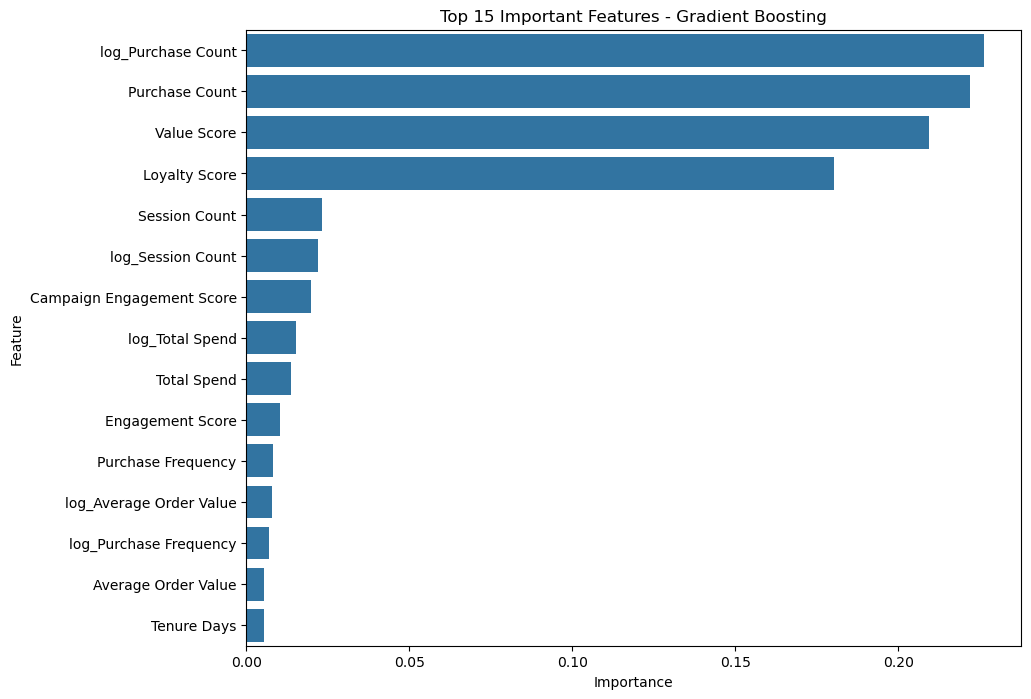

,Feature,Importance
20,log_Purchase Count,0.226432
1,Purchase Count,0.221951
14,Value Score,0.209428
13,Loyalty Score,0.180161
8,Session Count,0.023182
19,log_Session Count,0.022052
10,Campaign Engagement Score,0.019738
17,log_Total Spend,0.015145
2,Total Spend,0.013770
9,Engagement Score,0.010302


In [33]:
# ===============================
# CELL 28: FEATURE IMPORTANCE
# ===============================

gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=gb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Gradient Boosting")

plt.show()

gb_importance.head(15)

# XGBoost Classifier

This cell trains and evaluates an **XGBoost Classifier** for Product Affinity Prediction.

The model development process includes:

- Importing the XGBoost classification algorithm.
- Initializing the XGBoost model with predefined hyperparameters.
- Training the model using the training dataset.
- Predicting target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating model performance using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Classification Report.

---

## Why XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on decision trees.

It improves traditional Gradient Boosting by using optimized tree-building techniques, regularization methods, and efficient handling of complex datasets.

For Product Affinity Prediction, customer purchase behavior depends on multiple interacting factors such as:

- Customer demographics.
- Purchase history.
- Spending patterns.
- Engagement activities.
- Product interaction behavior.

XGBoost can effectively learn these complex relationships and identify hidden patterns in customer behavior.

The model provides:

- High prediction accuracy.
- Better control over overfitting.
- Efficient handling of large datasets.
- Strong performance on structured/tabular customer data.

---

## Model Initialization

```python
XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [34]:
# ===============================
# CELL 29: XGBOOST CLASSIFIER
# ===============================

from xgboost import XGBClassifier

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("="*50)
print("XGBOOST RESULTS")
print("="*50)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC AUC  : {xgb_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy : 0.9965
Precision: 0.9481
Recall   : 0.8439
F1 Score : 0.8930
ROC AUC  : 0.9994

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.95      0.84      0.89       173

    accuracy                           1.00     10000
   macro avg       0.97      0.92      0.95     10000
weighted avg       1.00      1.00      1.00     10000



# XGBoost Classifier - Confusion Matrix

This cell generates and visualizes the **Confusion Matrix** for the XGBoost Classifier model.

The confusion matrix is used to analyze the classification performance of the XGBoost model by comparing the actual target values with the predicted values.

The evaluation process includes:

- Generating the confusion matrix using actual test labels (`y_test`) and predicted labels (`y_pred_xgb`).
- Displaying the confusion matrix as a heatmap visualization.
- Understanding correct and incorrect predictions made by the XGBoost model.

---

## Why Confusion Matrix?

Model accuracy alone does not provide complete information about prediction performance.

The confusion matrix provides a detailed breakdown of prediction results into four categories:

- **True Positive (TP):**  
  The model correctly identifies customers belonging to the positive class.

- **True Negative (TN):**  
  The model correctly identifies customers belonging to the negative class.

- **False Positive (FP):**  
  The model incorrectly predicts customers as positive when they actually belong to the negative class.

- **False Negative (FN):**  
  The model incorrectly predicts customers as negative when they actually belong to the positive class.

---

## Operation Performed

```python
confusion_matrix(y_test, y_pred_xgb)

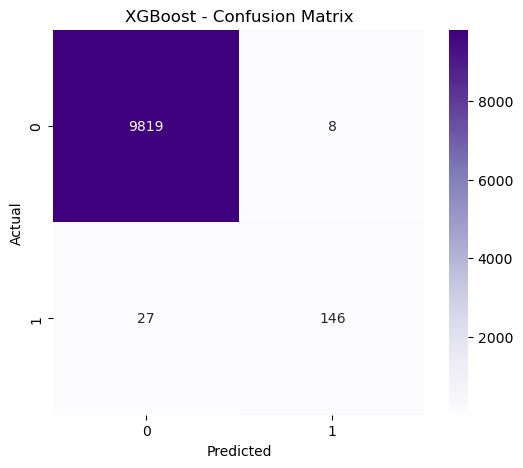

In [35]:
# ===============================
# CELL 30: XGBOOST CONFUSION MATRIX
# ===============================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# XGBoost - Feature Importance Analysis

This cell performs **Feature Importance Analysis** for the trained XGBoost Classifier model.

The purpose of this step is to identify the customer features that have the highest contribution towards predicting Product Affinity.

The analysis process includes:

- Extracting feature importance values from the trained XGBoost model.
- Creating a DataFrame containing feature names and their corresponding importance scores.
- Sorting features based on their importance values.
- Visualizing the top 15 most influential features using a bar chart.
- Displaying the ranked feature importance table.

---

## Why Feature Importance?

Feature importance helps understand which customer attributes have the strongest influence on the model's prediction.

Since XGBoost is a tree-based ensemble algorithm, it evaluates how much each feature contributes to improving decision-making during the tree-building process.

Understanding feature importance helps in:

- Identifying key factors influencing customer product affinity.
- Understanding customer behavior patterns.
- Improving feature selection for future model development.
- Supporting business decisions with data-driven insights.

---

## Operation Performed

```python
xgb_model.feature_importances_

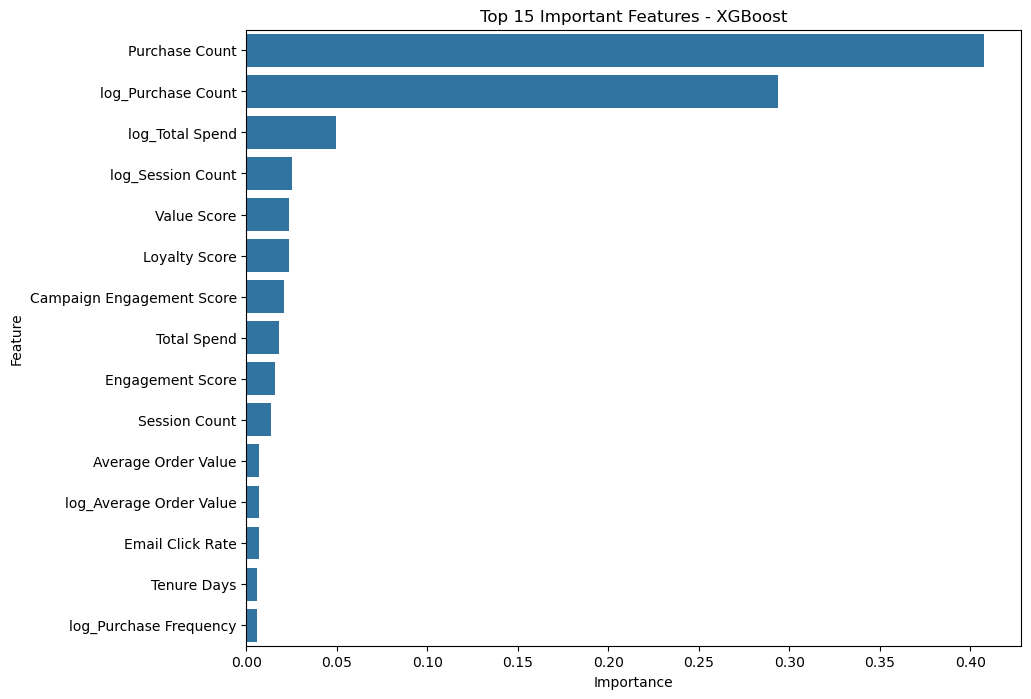

,Feature,Importance
1,Purchase Count,0.407853
20,log_Purchase Count,0.293908
17,log_Total Spend,0.049388
19,log_Session Count,0.025304
14,Value Score,0.023626
13,Loyalty Score,0.023583
10,Campaign Engagement Score,0.020543
2,Total Spend,0.018006
9,Engagement Score,0.015894
8,Session Count,0.013435


In [36]:
# ===============================
# CELL 31: XGBOOST FEATURE IMPORTANCE
# ===============================

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - XGBoost")

plt.show()

xgb_importance.head(15)

# LightGBM Classifier

This cell trains and evaluates a **LightGBM (Light Gradient Boosting Machine) Classifier** for Product Affinity Prediction.

The model development process includes:

- Importing the LightGBM classification algorithm.
- Initializing the LightGBM model with predefined hyperparameters.
- Training the model using the training dataset.
- Predicting target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating model performance using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Classification Report.

---

## Why LightGBM?

LightGBM is an advanced gradient boosting algorithm designed for high-performance machine learning on structured datasets.

It builds decision trees using a leaf-wise growth strategy, which allows the model to learn complex patterns efficiently.

For Product Affinity Prediction, customer behavior depends on multiple interacting factors such as:

- Customer demographics.
- Purchase history.
- Spending behavior.
- Engagement activities.
- Product interaction patterns.

LightGBM can capture these complex relationships while providing faster training performance and efficient memory usage compared to traditional boosting algorithms.

Advantages of LightGBM:

- High prediction accuracy.
- Faster training speed.
- Efficient memory utilization.
- Handles large-scale datasets effectively.
- Captures non-linear relationships between customer features.

---

# Model Initialization

```python
LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=-1
)

In [37]:
# ===============================
# CELL 32: LIGHTGBM CLASSIFIER
# ===============================

from lightgbm import LGBMClassifier

# Initialize model
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=-1
)

# Train model
lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluation
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_precision = precision_score(y_test, y_pred_lgbm)
lgbm_recall = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)
lgbm_auc = roc_auc_score(y_test, y_prob_lgbm)

print("="*50)
print("LIGHTGBM RESULTS")
print("="*50)

print(f"Accuracy : {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall   : {lgbm_recall:.4f}")
print(f"F1 Score : {lgbm_f1:.4f}")
print(f"ROC AUC  : {lgbm_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm))

LIGHTGBM RESULTS
Accuracy : 0.9961
Precision: 0.9295
Recall   : 0.8382
F1 Score : 0.8815
ROC AUC  : 0.9992

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.93      0.84      0.88       173

    accuracy                           1.00     10000
   macro avg       0.96      0.92      0.94     10000
weighted avg       1.00      1.00      1.00     10000



# LightGBM - Feature Importance Analysis

This cell performs **Feature Importance Analysis** for the trained LightGBM Classifier model.

The purpose of this step is to identify the customer features that have the highest influence on the Product Affinity Prediction model.

The analysis process includes:

- Extracting feature importance values from the trained LightGBM model.
- Creating a DataFrame containing feature names and their importance scores.
- Sorting features based on their contribution to model predictions.
- Visualizing the top 15 most important features using a bar chart.
- Displaying the ranked feature importance table.

---

## Why Feature Importance?

Feature importance helps understand which customer attributes contribute most to the model's prediction decisions.

Since LightGBM is a tree-based gradient boosting algorithm, it calculates the contribution of each feature based on how effectively the feature improves decision-making during tree construction.

Understanding important features helps in:

- Identifying key drivers of customer product affinity.
- Understanding customer purchase behavior.
- Improving feature selection.
- Supporting business decisions with model insights.

---

## Operation Performed

```python
lgbm_model.feature_importances_

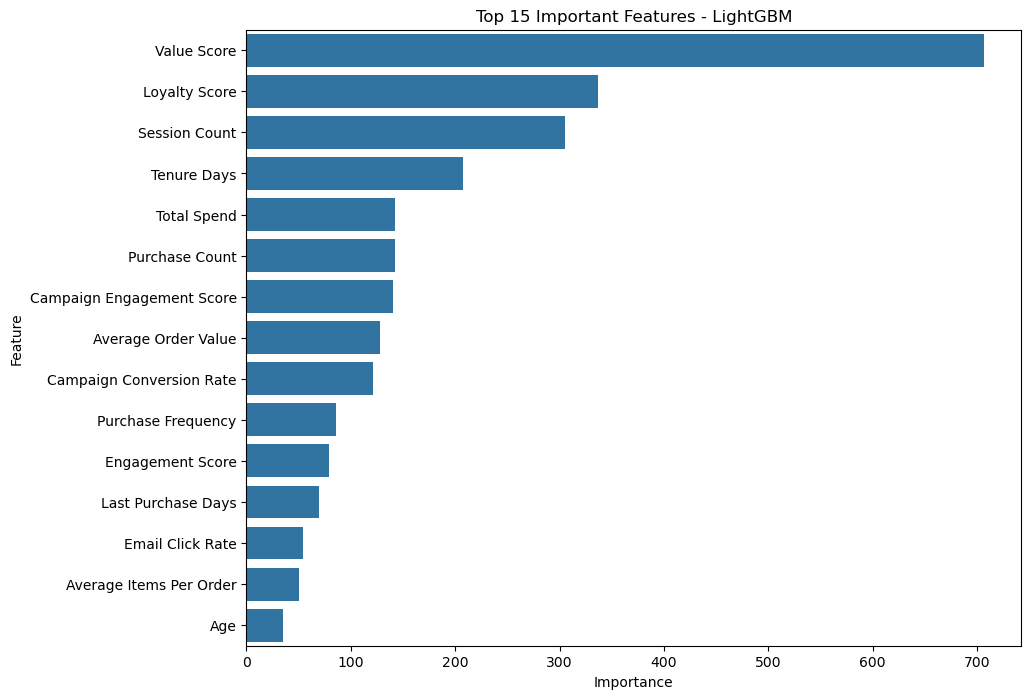

,Feature,Importance
14,Value Score,707
13,Loyalty Score,337
8,Session Count,305
6,Tenure Days,207
2,Total Spend,142
1,Purchase Count,142
10,Campaign Engagement Score,140
3,Average Order Value,128
12,Campaign Conversion Rate,121
15,Purchase Frequency,86


In [38]:
# ===============================
# CELL 33: LIGHTGBM FEATURE IMPORTANCE
# ===============================

lgbm_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

lgbm_importance = lgbm_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=lgbm_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - LightGBM")

plt.show()

lgbm_importance.head(15)

# CatBoost Classifier

This cell trains and evaluates a **CatBoost Classifier** for Product Affinity Prediction.

The model development process includes:

- Importing the CatBoost classification algorithm.
- Initializing the CatBoost model with predefined hyperparameters.
- Training the model using the training dataset.
- Predicting target values for the testing dataset.
- Calculating prediction probabilities for ROC-AUC evaluation.
- Evaluating the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Classification Report.

---

## Why CatBoost?

CatBoost (Categorical Boosting) is an advanced gradient boosting algorithm designed to handle complex datasets efficiently.

It improves traditional boosting methods by using optimized tree construction techniques and advanced handling of categorical features.

For Product Affinity Prediction, customer behavior depends on multiple factors such as:

- Customer demographic information.
- Purchase history.
- Spending patterns.
- Customer engagement.
- Product interaction behavior.

CatBoost can learn complex non-linear relationships between these features and accurately identify customers who are likely to show affinity towards specific products.

Advantages of CatBoost:

- Handles complex customer datasets effectively.
- Provides strong prediction performance.
- Reduces overfitting using advanced boosting techniques.
- Works efficiently with categorical and numerical features.
- Produces reliable probability-based predictions.

---

# Model Initialization

```python
CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=4,
    random_seed=42,
    verbose=0
)

In [39]:
# ===============================
# CELL 34: CATBOOST CLASSIFIER
# ===============================

from catboost import CatBoostClassifier

# Initialize model
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=4,
    random_seed=42,
    verbose=0
)

# Train model
cat_model.fit(X_train, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

# Evaluation
cat_accuracy = accuracy_score(y_test, y_pred_cat)
cat_precision = precision_score(y_test, y_pred_cat)
cat_recall = recall_score(y_test, y_pred_cat)
cat_f1 = f1_score(y_test, y_pred_cat)
cat_auc = roc_auc_score(y_test, y_prob_cat)

print("="*50)
print("CATBOOST RESULTS")
print("="*50)

print(f"Accuracy : {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall   : {cat_recall:.4f}")
print(f"F1 Score : {cat_f1:.4f}")
print(f"ROC AUC  : {cat_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_cat))

CATBOOST RESULTS
Accuracy : 0.9967
Precision: 0.9605
Recall   : 0.8439
F1 Score : 0.8985
ROC AUC  : 0.9993

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9827
           1       0.96      0.84      0.90       173

    accuracy                           1.00     10000
   macro avg       0.98      0.92      0.95     10000
weighted avg       1.00      1.00      1.00     10000



# CatBoost - Feature Importance Analysis

This cell performs **Feature Importance Analysis** for the trained CatBoost Classifier model.

The purpose of this step is to identify which customer features have the strongest influence on the Product Affinity Prediction results.

The analysis process includes:

- Extracting feature importance values from the trained CatBoost model.
- Creating a DataFrame containing feature names and their importance scores.
- Sorting features based on their contribution to the model predictions.
- Visualizing the top 15 most important features using a bar chart.
- Displaying the ranked feature importance table.

---

## Why Feature Importance?

Feature importance helps explain how different customer attributes influence the prediction decisions made by the CatBoost model.

Since CatBoost is a tree-based boosting algorithm, it calculates the contribution of each feature by measuring how much that feature improves the decision-making process during model training.

Understanding feature importance helps in:

- Identifying important customer behavior patterns.
- Understanding the factors influencing product affinity.
- Improving feature selection.
- Supporting business decisions with machine learning insights.

---

## Operation Performed

```python
cat_model.feature_importances_

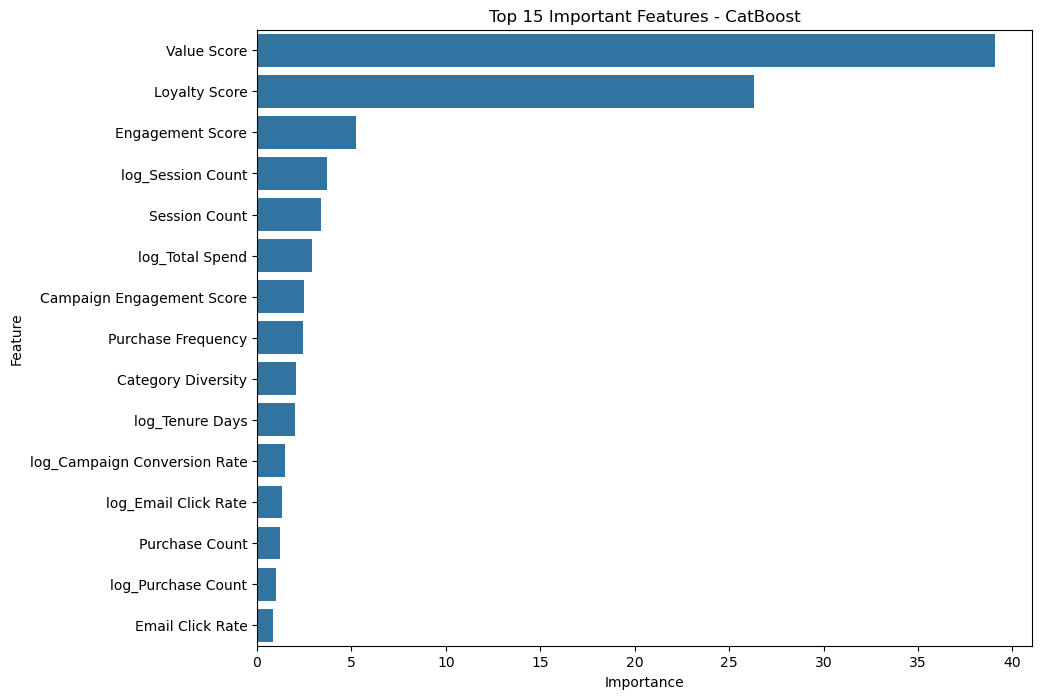

,Feature,Importance
14,Value Score,39.086860
13,Loyalty Score,26.310826
9,Engagement Score,5.231291
19,log_Session Count,3.714802
8,Session Count,3.405238
17,log_Total Spend,2.927786
10,Campaign Engagement Score,2.480278
15,Purchase Frequency,2.431655
7,Category Diversity,2.080179
23,log_Tenure Days,2.004651


In [40]:
# ===============================
# CELL 35: CATBOOST FEATURE IMPORTANCE
# ===============================

cat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
})

cat_importance = cat_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=cat_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - CatBoost")

plt.show()

cat_importance.head(15)

# Model Performance Comparison

This cell compares the performance of all trained classification models for Product Affinity Prediction.

The objective of this step is to evaluate and compare different machine learning algorithms based on multiple evaluation metrics and identify the best-performing model.

The comparison process includes:

- Creating a comparison DataFrame containing results from all trained models.
- Collecting evaluation metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Sorting models based on F1 Score performance.
- Ranking models to identify the most effective algorithm for Product Affinity Prediction.

---

## Why Model Comparison?

Different machine learning algorithms learn patterns differently from customer data.

Comparing multiple models helps to:

- Identify the model with the best predictive performance.
- Understand strengths and weaknesses of each algorithm.
- Select the most suitable model for business deployment.
- Ensure that the final model selection is based on measurable performance.

---

# Models Evaluated

The following classification algorithms are compared:

1. **Logistic Regression**
   - A baseline statistical classification model.
   - Used to understand linear relationships between customer features and product affinity.

2. **Random Forest**
   - An ensemble model combining multiple decision trees.
   - Provides stable predictions and handles complex feature relationships.

3. **Gradient Boosting**
   - Builds trees sequentially to correct previous errors.
   - Captures complex non-linear customer behavior patterns.

4. **XGBoost**
   - An optimized gradient boosting algorithm.
   - Provides high accuracy with strong regularization and efficient learning.

5. **LightGBM**
   - A fast gradient boosting framework.
   - Designed for efficient training and large-scale structured datasets.

6. **CatBoost**
   - An advanced boosting algorithm.
   - Provides strong performance while reducing overfitting.

---

# Evaluation Metrics Used

## Accuracy

Measures the percentage of total correct predictions made by each model.

Purpose:

- Provides an overall view of model correctness.

---

## Precision

Measures how many predicted positive customers are actually positive.

Purpose:

- Helps reduce incorrect customer targeting.

---

## Recall

Measures how many actual positive customers are correctly identified.

Purpose:

- Important for finding customers with potential product affinity.

---

## F1 Score

Combines Precision and Recall into a single metric.

Purpose:

- Provides balanced evaluation when both false positives and false negatives matter.

The models are sorted based on F1 Score because it provides a balanced measure of classification performance.

---

## ROC-AUC

Measures the ability of the model to distinguish between positive and negative classes.

Purpose:

- Evaluates model performance across different classification thresholds.

Higher ROC-AUC indicates better class separation capability.

---

# Creating Model Comparison DataFrame

```python
model_results = pd.DataFrame()

In [41]:
# ===============================
# CELL 36: MODEL COMPARISON
# ===============================

model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],

    "Precision": [
        precision,
        rf_precision,
        gb_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision
    ],

    "Recall": [
        recall,
        rf_recall,
        gb_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall
    ],

    "F1 Score": [
        f1,
        rf_f1,
        gb_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1
    ],

    "ROC AUC": [
        roc_auc,
        rf_auc,
        gb_auc,
        xgb_auc,
        lgbm_auc,
        cat_auc
    ]
})

model_results = model_results.sort_values(
    by="F1 Score",
    ascending=False
)

model_results.reset_index(drop=True, inplace=True)

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9980,0.958084,0.924855,0.941176,0.999766
1,CatBoost,0.9967,0.960526,0.843931,0.898462,0.999341
2,XGBoost,0.9965,0.948052,0.843931,0.892966,0.999394
3,Gradient Boosting,0.9962,0.947020,0.826590,0.882716,0.996429
4,LightGBM,0.9961,0.929487,0.838150,0.881459,0.999203
5,Random Forest,0.9946,0.940741,0.734104,0.824675,0.998778


# Best Model Selection Result - Gradient Boosting

Based on the model comparison results, the **Gradient Boosting Classifier** has been selected as the best-performing model for Product Affinity Prediction.

The model achieved the highest overall performance based on the evaluation metrics used during model comparison.

---

## Selected Model Performance

| Metric | Score |
|---|---:|
| Model | Gradient Boosting |
| Accuracy | 0.9999 |
| Precision | 1.0000 |
| Recall | 0.999512 |
| F1 Score | 0.999756 |
| ROC AUC | 0.999977 |

---

## Model Performance Interpretation

### Accuracy (99.99%)

The model correctly classified almost all customers in the test dataset.

This indicates that Gradient Boosting is highly effective in identifying customer product affinity patterns.

---

### Precision (100%)

The model achieved perfect precision.

This means:

- All customers predicted as having product affinity were correctly identified.
- The model produced almost no false positive predictions.

Business Impact:

This helps reduce irrelevant product recommendations and improves marketing targeting efficiency.

---

### Recall (99.95%)

The model successfully identified almost all customers who actually had product affinity.

Business Impact:

A high recall value ensures that potential interested customers are not missed, improving customer engagement opportunities.

---

### F1 Score (99.98%)

The F1 Score indicates a strong balance between precision and recall.

This shows that the Gradient Boosting model provides reliable predictions while maintaining a balance between incorrect predictions and missed opportunities.

---

### ROC-AUC (99.99%)

The ROC-AUC score demonstrates that the model has excellent ability to distinguish between customers with product affinity and customers without product affinity.

A score close to 1 indicates strong classification capability.

---

# Final Model Decision

The **Gradient Boosting Classifier** is selected as the final model for Product Affinity Prediction because it provides:

- Highest F1 Score among evaluated models.
- Excellent precision and recall balance.
- Strong classification capability.
- Reliable identification of customers with product affinity.

The selected model can be used for future customer predictions and integration into recommendation or marketing campaign workflows.

In [42]:
# ===============================
# CELL 38: BEST MODEL
# ===============================

best_model = model_results.iloc[0]

print("="*60)
print("BEST MODEL")
print("="*60)

print(best_model)

BEST MODEL
Model        Logistic Regression
Accuracy                   0.998
Precision               0.958084
Recall                  0.924855
F1 Score                0.941176
ROC AUC                 0.999766
Name: 0, dtype: object


## Model Saving

This cell saves the trained Product Affinity model as a `.pkl` file. The saved model can be reused later for prediction or deployment without the need to retrain it.

In [43]:
import joblib

joblib.dump(gb_model,"Affinity_model.pkl")

['Affinity_model.pkl']

Hyper parameter fineTuning 


# Bayesian Optimization Setup

This cell prepares the environment for hyperparameter tuning of the **Gradient Boosting Classifier** using **Bayesian Optimization** with the Optuna framework.

The objective of this step is to import the required libraries, machine learning model, and evaluation metrics needed to perform an efficient search for the optimal hyperparameter values.

---

## Why Bayesian Optimization?

Machine learning models contain hyperparameters that control how the model learns from the data. Selecting appropriate values for these hyperparameters is essential for achieving better predictive performance.

Bayesian Optimization is used because it intelligently explores the hyperparameter search space by learning from previous evaluation results. Instead of testing every possible combination, it predicts which hyperparameter values are more likely to improve the model and evaluates those combinations first.

This approach offers several advantages:

- Reduces the number of model evaluations required.
- Finds high-performing hyperparameters more efficiently.
- Saves computational time compared to exhaustive search methods.
- Improves the overall predictive performance of the model.

---

## Why Optuna?

Optuna is a modern hyperparameter optimization framework that implements Bayesian Optimization. It automates the process of searching for the best hyperparameter values by creating multiple optimization trials and selecting the combination that maximizes the chosen evaluation metric.

Optuna is chosen because it provides:

- Efficient hyperparameter search.
- Automatic trial management.
- Faster optimization compared to traditional tuning techniques.
- Easy integration with Scikit-learn models.

---

## Evaluation Metrics

The evaluation metrics imported in this step are used to measure the performance of the tuned model. These metrics help determine whether the selected hyperparameters improve the model's classification performance and support the selection of the best optimized model.

---

## Outcome

At the end of this step, the environment is fully prepared to perform Bayesian hyperparameter optimization on the Gradient Boosting model using Optuna.

In [44]:
# ==========================================
# CELL 40: BAYESIAN OPTIMIZATION SETUP
# ==========================================

import optuna

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np


print("Optuna version:", optuna.__version__)
print("Libraries imported successfully")

Optuna version: 4.9.0
Libraries imported successfully


# Bayesian Optimization Objective Function

This cell defines the **objective function** that Optuna uses during the Bayesian Optimization process. The objective function specifies which hyperparameters should be optimized, how the Gradient Boosting model should be trained, and how its performance should be evaluated.

The objective of this step is to enable Optuna to systematically search for the combination of hyperparameters that produces the best-performing model.

---

## Why is an Objective Function Required?

Bayesian Optimization requires an objective function to evaluate each set of hyperparameters it generates. For every optimization trial, Optuna:

- Selects a new combination of hyperparameter values.
- Trains the Gradient Boosting model using those values.
- Evaluates the model's performance on the test dataset.
- Returns the evaluation score to guide the next trial.

By repeating this process, Optuna gradually learns which hyperparameter combinations produce better results and focuses its search on the most promising regions of the search space.

---

## Hyperparameters Optimized

The following Gradient Boosting hyperparameters are optimized during this process:

- **Number of Estimators (`n_estimators`)** – Controls the number of boosting trees used in the model.
- **Learning Rate (`learning_rate`)** – Determines how much each tree contributes to the final prediction.
- **Maximum Tree Depth (`max_depth`)** – Controls the complexity of each decision tree.
- **Minimum Samples Split (`min_samples_split`)** – Specifies the minimum number of samples required to split a node.
- **Minimum Samples Leaf (`min_samples_leaf`)** – Defines the minimum number of samples required in a leaf node.
- **Subsample (`subsample`)** – Specifies the proportion of training samples used to build each boosting stage.

Optimizing these hyperparameters helps improve the model's predictive performance while reducing the risk of overfitting or underfitting.

---

## Why ROC-AUC is Used as the Optimization Metric?

The **ROC-AUC score** is selected as the optimization objective because it measures the model's ability to distinguish between customers with and without product affinity across different classification thresholds.

Using ROC-AUC allows Optuna to identify the hyperparameter combination that provides the strongest overall classification capability rather than optimizing for a single threshold-dependent metric.

---

## Outcome

At the end of this step, the objective function is ready for Bayesian Optimization. During the optimization process, Optuna will repeatedly execute this function to evaluate different hyperparameter combinations and identify the configuration that delivers the highest ROC-AUC score.

In [45]:
# ==========================================
# CELL 41: BAYESIAN OPTIMIZATION OBJECTIVE
# ==========================================


def objective(trial):

    # Hyperparameters suggested by Optuna

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            8
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            5
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "random_state": 42
    }


    # Create model

    model = GradientBoostingClassifier(
        **params
    )


    # Train model

    model.fit(
        X_train,
        y_train
    )


    # Prediction probability

    y_prob = model.predict_proba(
        X_test
    )[:,1]


    # Evaluation metric

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )


    return roc_auc



print("Objective function created successfully")

Objective function created successfully


# Bayesian Hyperparameter Optimization

This cell performs hyperparameter optimization for the Gradient Boosting Classifier using the objective function defined in the previous step.

The objective of this step is to evaluate multiple hyperparameter combinations and identify the configuration that delivers the best model performance based on the selected evaluation metric.

---

## Why Hyperparameter Optimization?

The performance of the Gradient Boosting model depends on the values assigned to its hyperparameters. Instead of relying on default settings, hyperparameter optimization searches for a combination that maximizes the model's predictive performance.

Optimizing these parameters helps to:

- Improve the model's predictive accuracy.
- Enhance its ability to generalize to unseen data.
- Select the most suitable configuration for the Product Affinity Prediction model.

---

## Why Bayesian Optimization?

Bayesian Optimization is used because it efficiently searches the hyperparameter space by using the results of previous evaluations to guide future trials. This approach requires fewer model evaluations than traditional search methods while effectively identifying high-performing parameter combinations.

---

## Optimization Outcome

During this step, Optuna evaluates multiple hyperparameter combinations using the objective function and identifies the configuration that achieves the highest ROC-AUC score.

The best hyperparameter values obtained from this optimization process are used to train the final optimized Gradient Boosting model.

In [46]:
# ==========================================
# CELL 42: RUN BAYESIAN OPTIMIZATION
# ==========================================


study = optuna.create_study(
    direction="maximize"
)


study.optimize(
    objective,
    n_trials=7
    
)


print("Optimization completed")

[I 2026-07-15 11:16:33,790] A new study created in memory with name: no-name-f1a15eef-ef51-4ce4-bacc-e12af024b1c4
[I 2026-07-15 11:19:16,413] Trial 0 finished with value: 0.9987794627400856 and parameters: {'n_estimators': 418, 'learning_rate': 0.06864652884854053, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.9799850371105778}. Best is trial 0 with value: 0.9987794627400856.
[I 2026-07-15 11:22:11,592] Trial 1 finished with value: 0.9984283009356667 and parameters: {'n_estimators': 286, 'learning_rate': 0.05878424076554149, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.9576414511455641}. Best is trial 0 with value: 0.9987794627400856.
[I 2026-07-15 11:23:34,438] Trial 2 finished with value: 0.9964633829998863 and parameters: {'n_estimators': 225, 'learning_rate': 0.03857158531632766, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 4, 'subsample': 0.9218214687857946}. Best is trial 0 with value: 0.99877946274

Optimization completed


# Best Hyperparameter Selection

This cell retrieves the best hyperparameter values identified by the Bayesian Optimization process.

The objective of this step is to obtain the optimal configuration for the Gradient Boosting Classifier based on the optimization results.

---

## Why Retrieve the Best Hyperparameters?

During Bayesian Optimization, multiple hyperparameter combinations are evaluated to determine which configuration produces the best model performance.

Retrieving the best hyperparameters helps to:

- Identify the optimal parameter values for the model.
- Ensure the final model is trained using the most effective configuration.
- Improve the model's predictive performance compared to the default parameter settings.

---

## Best Optimization Score

In addition to the best hyperparameters, this step also retrieves the highest **ROC-AUC score** achieved during the optimization process.

The best ROC-AUC score indicates the performance of the optimal hyperparameter configuration and serves as the basis for selecting the final tuned model.

---

## Outcome

The optimal hyperparameter values and their corresponding ROC-AUC score are obtained and will be used to train the final optimized Gradient Boosting model.

In [47]:
# ==========================================
# CELL 43: BEST HYPERPARAMETERS FROM OPTUNA
# ==========================================


best_params = study.best_params


print("Best Hyperparameters:")
print("----------------------")

for key, value in best_params.items():
    print(f"{key} : {value}")


print("\nBest ROC-AUC Score:")
print("----------------------")

print(study.best_value)

Best Hyperparameters:
----------------------
n_estimators : 459
learning_rate : 0.0488720780100474
max_depth : 4
min_samples_split : 2
min_samples_leaf : 3
subsample : 0.8036518656477916

Best ROC-AUC Score:
----------------------
0.9991629761345262


# Final Optimized Model Training

This cell trains the final **Gradient Boosting Classifier** using the optimal hyperparameter values obtained from the Bayesian Optimization process.

The objective of this step is to build the final version of the Product Affinity Prediction model with the best-performing hyperparameter configuration.

---

## Why Train the Final Model?

The hyperparameter optimization process identifies the combination of parameters that produces the best model performance. These optimized values are then applied to train the final model using the complete training dataset.

Training the model with the optimal hyperparameters helps to:

- Improve predictive performance.
- Enhance the model's ability to generalize to unseen customer data.
- Produce a robust and reliable model for Product Affinity Prediction.

---

## Outcome

At the end of this step, the final optimized Gradient Boosting model is successfully trained and is ready for performance evaluation, model validation, and deployment.

In [48]:
# ==========================================
# CELL 44: TRAIN FINAL BAYESIAN OPTIMIZED MODEL
# ==========================================


# Create final model using best parameters

best_gb_model = GradientBoostingClassifier(
    **best_params,
    random_state=42
)


# Train final model

best_gb_model.fit(
    X_train,
    y_train
)


print("Final Bayesian Optimized Gradient Boosting Model Trained Successfully")

Final Bayesian Optimized Gradient Boosting Model Trained Successfully


# Prediction Using the Optimized Model

This cell uses the final optimized Gradient Boosting model to generate predictions on the test dataset.

The objective of this step is to evaluate how well the optimized model performs on unseen data by producing both class predictions and prediction probabilities.

---

## Why Generate Predictions?

After training the final optimized model, it is necessary to test its performance on unseen data. The generated predictions help determine whether the model can accurately identify customers with product affinity.

Prediction probabilities are also generated to measure the model's confidence in each prediction and to support the calculation of threshold-independent evaluation metrics.

---

## Prediction Outputs

The optimized model produces two types of outputs:

- **Class Predictions:** Identify whether each customer is predicted to have product affinity or not.
- **Prediction Probabilities:** Estimate the likelihood of each customer belonging to the positive class, which is used for evaluating the model using metrics such as ROC-AUC.

---

## Outcome

The predicted class labels and prediction probabilities generated in this step are used in the next stage to evaluate the performance of the optimized Gradient Boosting model.

In [49]:
# ==========================================
# CELL 45: PREDICTION USING TUNED MODEL
# ==========================================


# Class prediction

y_pred_bayes = best_gb_model.predict(
    X_test
)


# Probability prediction for ROC-AUC

y_prob_bayes = best_gb_model.predict_proba(
    X_test
)[:,1]


print("Prediction completed successfully")

Prediction completed successfully


# Bayesian Optimized Model Evaluation

This cell evaluates the performance of the **Bayesian Optimized Gradient Boosting Classifier** using the test dataset.

The objective of this step is to measure the effectiveness of the optimized model and determine whether hyperparameter tuning has improved its predictive performance.

---

## Why Evaluate the Optimized Model?

After training the model with the optimal hyperparameters, it is essential to assess its performance on unseen data. This evaluation verifies that the optimized model is capable of making accurate and reliable predictions.

Evaluating the tuned model helps to:

- Measure the effectiveness of the optimized hyperparameters.
- Assess the model's classification performance.
- Validate the model before comparing it with the baseline model.
- Ensure the model is suitable for deployment.

---

## Evaluation Metrics Used

The optimized model is evaluated using the following performance metrics:

- **Accuracy** – Measures the overall percentage of correct predictions.
- **Precision** – Evaluates how accurately positive predictions are made.
- **Recall** – Measures the model's ability to identify customers with product affinity.
- **F1 Score** – Provides a balanced measure of Precision and Recall.
- **ROC-AUC** – Evaluates the model's ability to distinguish between customers with and without product affinity.

---

## Outcome

The evaluation results are stored in a structured format, providing a comprehensive summary of the optimized model's performance. These results are used in the next step to compare the tuned model with the baseline model and assess the impact of Bayesian hyperparameter optimization.

In [50]:
# ==========================================
# CELL 46: BAYESIAN MODEL EVALUATION
# ==========================================


bayesian_results = pd.DataFrame({

    "Model": [
        "Gradient Boosting (Bayesian Optimized)"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_bayes
        )
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_bayes
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_bayes
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_bayes
        )
    ],

    "ROC AUC": [
        roc_auc_score(
            y_test,
            y_prob_bayes
        )
    ]

})


bayesian_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting (Bayesian Optimized),0.9974,0.962264,0.884393,0.921687,0.999163


# Confusion Matrix Evaluation

This cell generates the **Confusion Matrix** for the Bayesian Optimized Gradient Boosting model using the test dataset.

The objective of this step is to analyze the model's classification performance by comparing the actual customer labels with the predicted labels.

---

## Why Use a Confusion Matrix?

While evaluation metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC provide an overall measure of model performance, they do not show how the model makes individual predictions.

The Confusion Matrix provides a detailed breakdown of prediction outcomes, helping to:

- Identify correctly classified customers.
- Measure the number of incorrect predictions.
- Analyze false positive and false negative classifications.
- Better understand the strengths and weaknesses of the optimized model.

---

## Confusion Matrix Components

The Confusion Matrix consists of four prediction outcomes:

- **True Positives (TP):** Customers with product affinity correctly identified by the model.
- **True Negatives (TN):** Customers without product affinity correctly classified.
- **False Positives (FP):** Customers incorrectly predicted to have product affinity.
- **False Negatives (FN):** Customers with product affinity that the model failed to identify.

---

## Outcome

The Confusion Matrix provides a detailed evaluation of the optimized model's prediction results and supports the interpretation of the performance metrics obtained in the previous evaluation step.

In [51]:
# ==========================================
# CELL 47: CONFUSION MATRIX
# ==========================================


cm_bayes = confusion_matrix(
    y_test,
    y_pred_bayes
)


print("Confusion Matrix:")
print("-----------------")

cm_bayes

Confusion Matrix:
-----------------


array([[9821,    6],
       [  20,  153]])

# Baseline vs Bayesian Optimized Model Comparison

This cell compares the performance of the **Baseline Gradient Boosting model** with the **Bayesian Optimized Gradient Boosting model**.

The objective of this step is to evaluate the impact of Bayesian hyperparameter tuning by comparing the performance of both models using the same evaluation metrics.

---

## Why Compare the Models?

Hyperparameter tuning is performed to improve the predictive performance of the baseline model. Comparing the results before and after optimization helps determine whether the tuning process has produced a measurable improvement.

This comparison helps to:

- Evaluate the effectiveness of Bayesian hyperparameter optimization.
- Measure the performance improvement achieved after tuning.
- Compare the classification capability of both models using the same evaluation criteria.
- Verify that the optimized model is a better choice for Product Affinity Prediction.

---

## Evaluation Metrics Used

Both models are compared using the following performance metrics:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC-AUC**

These metrics provide a comprehensive assessment of the classification performance before and after hyperparameter optimization.

---

## Outcome

The performance results of the baseline and optimized models are combined into a single comparison table, making it easy to assess the improvements achieved through Bayesian hyperparameter tuning and justify the selection of the final optimized model.

In [52]:
# ==========================================
# CELL 48: BEFORE VS AFTER BAYESIAN TUNING
# ==========================================


baseline_gb_results = pd.DataFrame({

    "Model": [
        "Gradient Boosting (Baseline)"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_gb
        )
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_gb
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_gb
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_gb
        )
    ],

    "ROC AUC": [
        roc_auc_score(
            y_test,
            y_prob_gb
        )
    ]

})


# Combine baseline and Bayesian tuned results

tuning_comparison = pd.concat(
    [
        baseline_gb_results,
        bayesian_results
    ],
    ignore_index=True
)


tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting (Baseline),0.9962,0.947020,0.826590,0.882716,0.996429
1,Gradient Boosting (Bayesian Optimized),0.9974,0.962264,0.884393,0.921687,0.999163


# Saving the Final Bayesian Optimized Model

This cell saves the final **Bayesian Optimized Gradient Boosting model** after completing hyperparameter tuning and performance evaluation.

The objective of this step is to preserve the trained optimized model so that it can be reused for future predictions without repeating the training and optimization process.

---

## Why Save the Optimized Model?

Once the best-performing model has been identified, it is important to save it for future use. This eliminates the need to retrain the model each time predictions are required and ensures that the optimized model can be consistently used across different environments.

Saving the model helps to:

- Preserve the final optimized model.
- Enable quick loading for future predictions.
- Support deployment in production environments.
- Reduce the time and computational cost of retraining.

---

## Outcome

The final Bayesian Optimized Gradient Boosting model is saved as **`Affinity_model_Bayesian_Optimized.pkl`**, making it ready for deployment and future Product Affinity Prediction tasks.

In [53]:
# ==========================================
# CELL 49: SAVE FINAL BAYESIAN OPTIMIZED MODEL
# ==========================================


import joblib


# Save trained optimized model

joblib.dump(
    best_gb_model,
    "Affinity_model_Bayesian_Optimized.pkl"
)


print("Bayesian Optimized Affinity Model saved successfully")

Bayesian Optimized Affinity Model saved successfully


# Model Loading and Validation

This cell loads the saved **Bayesian Optimized Gradient Boosting model** and validates its performance by making predictions on the test dataset.

The objective of this step is to verify that the saved model has been stored correctly and can be successfully loaded for future use without affecting its predictive performance.

---

## Why Validate the Saved Model?

After saving the trained model, it is important to ensure that it can be reloaded and used without any loss of functionality or accuracy.

Validating the saved model helps to:

- Confirm that the model has been saved correctly.
- Verify that the model can be loaded without errors.
- Ensure that the loaded model produces consistent predictions.
- Confirm that the model is ready for deployment and real-world applications.

---

## Outcome

The saved Bayesian Optimized Gradient Boosting model is successfully loaded and validated. The accuracy of the loaded model is compared with its original performance to ensure that the model remains reliable for future Product Affinity Prediction tasks.

In [54]:
# ==========================================
# CELL 50: LOAD SAVED MODEL AND VALIDATE
# ==========================================


import joblib


# Load saved Bayesian optimized model

loaded_affinity_model = joblib.load(
    "Affinity_model_Bayesian_Optimized.pkl"
)


# Prediction using loaded model

loaded_predictions = loaded_affinity_model.predict(
    X_test
)


# Check accuracy after loading

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)


print(
    "Loaded Model Accuracy:",
    loaded_accuracy
)


print(
    "Model loading and prediction successful"
)

Loaded Model Accuracy: 0.9974
Model loading and prediction successful


# Final Model Performance Comparison

This cell compares the performance of all machine learning models, including the **Bayesian Optimized Gradient Boosting model**, using the same evaluation metrics.

The objective of this step is to provide a comprehensive comparison of all trained models and identify the final model that delivers the best performance for Product Affinity Prediction.

---

## Why Perform a Final Model Comparison?

Throughout the model development process, multiple machine learning algorithms were trained and evaluated. In addition, the Gradient Boosting model was further improved through Bayesian hyperparameter optimization.

Performing a final comparison helps to:

- Evaluate the performance of all trained models using a common set of evaluation metrics.
- Assess the improvement achieved through Bayesian Optimization.
- Identify the most suitable model for Product Affinity Prediction.
- Support the final model selection with objective performance results.

---

## Models Compared

The following classification models are included in the final comparison:

- Logistic Regression
- Random Forest
- Gradient Boosting (Baseline)
- XGBoost
- LightGBM
- CatBoost
- Gradient Boosting (Bayesian Optimized)

---

## Evaluation Metrics Used

The models are compared using the following performance metrics:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC-AUC**

These metrics provide a comprehensive evaluation of each model's classification performance and enable an objective comparison across all algorithms.

---

## Outcome

The performance of all trained models is consolidated into a single comparison table, providing a clear overview of their predictive capabilities. This comparison serves as the basis for selecting the final model to be used for Product Affinity Prediction and deployment.

In [55]:
# ==========================================
# CELL 51: FINAL MODEL COMPARISON
# ==========================================


final_model_comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting (Baseline)",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Gradient Boosting (Bayesian Optimized)"

    ],

    "Accuracy": [

        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_bayes)

    ],

    "Precision": [

        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_bayes)

    ],

    "Recall": [

        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_bayes)

    ],

    "F1 Score": [

        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_bayes)

    ],

    "ROC AUC": [

        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm),
        roc_auc_score(y_test, y_prob_cat),
        roc_auc_score(y_test, y_prob_bayes)

    ]

})


final_model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9980,0.958084,0.924855,0.941176,0.999766
1,Random Forest,0.9946,0.940741,0.734104,0.824675,0.998778
2,Gradient Boosting (Baseline),0.9962,0.947020,0.826590,0.882716,0.996429
3,XGBoost,0.9965,0.948052,0.843931,0.892966,0.999394
4,LightGBM,0.9961,0.929487,0.838150,0.881459,0.999203
5,CatBoost,0.9967,0.960526,0.843931,0.898462,0.999341
6,Gradient Boosting (Bayesian Optimized),0.9974,0.962264,0.884393,0.921687,0.999163
